In [1]:
import requests
import time
import json

In [2]:
BASE_URL = "https://arctic-shift.photon-reddit.com"

def sanity_check():
    """
    test a small query to verify:
    (1) API is up
    (2) response schema matches expectations
    (3) our time window returns data
    """
    params = {
        "subreddit": "unitedkingdom",
        "query": "ChatGPT",
        "after": "2024-10-01",
        "before": "2024-10-31",
        "limit": 5,
        "sort": "desc",
        "fields": "id,subreddit,author,created_utc,title,selftext,score,num_comments,url"
    }
    r = requests.get(f"{BASE_URL}/api/posts/search", params=params, timeout=30)
    print(f"HTTP status:            {r.status_code}")
    print(f"Rate-limit remaining:   {r.headers.get('X-RateLimit-Remaining')}")
    print(f"Rate-limit reset:       {r.headers.get('X-RateLimit-Reset')}")
    print()
    if r.status_code != 200:
        print("!!! non-200 response, aborting")
        print(r.text[:500])
        return None
    
    data = r.json()
    print(f"top-level keys:         {list(data.keys())}")
    posts = data.get("data", [])
    print(f"number of posts returned: {len(posts)}")
    print()
    
    if posts:
        p = posts[0]
        print("first post - all fields returned:")
        for k, v in p.items():
            preview = str(v)[:80]
            print(f"  {k:20s} | {preview}")
    
    return data

sanity_data = sanity_check()

HTTP status:            200
Rate-limit remaining:   None
Rate-limit reset:       29

top-level keys:         ['data', 'meta']
number of posts returned: 1

first post - all fields returned:
  author               | Unhappy-Mood-7794
  created_utc          | 1727924323
  id                   | 1fuy5mv
  num_comments         | 0
  score                | 1
  selftext             | 
  subreddit            | unitedkingdom
  title                | ChatGPT
  url                  | https://chatgpt.com/share/66fe082c-c308-8005-a77d-1c37b4cc791a


In [3]:
import os
import json
import time
import requests
import pandas as pd
from pathlib import Path

In [4]:
BASE_URL = "https://arctic-shift.photon-reddit.com"
OUT_DIR = Path("reddit_raw")
OUT_DIR.mkdir(exist_ok=True)

# Time window
AFTER  = "2024-06-01"
BEFORE = "2025-06-01"

FIELDS = "id,subreddit,author,created_utc,title,selftext,score,num_comments,url,link_flair_text"

def fetch_page(subreddit, query, after, before, limit=100, sort="asc"):
    """One API call. Returns list of post dicts."""
    params = {
        "subreddit": subreddit,
        "query":     query,
        "after":     after,
        "before":    before,
        "limit":     limit,
        "sort":      sort,
        "fields":    FIELDS,
    }
    r = requests.get(f"{BASE_URL}/api/posts/search", params=params, timeout=60)
    if r.status_code == 429:
        wait = int(r.headers.get("X-RateLimit-Reset", 30)) + 2
        print(f"    [429] rate limited, sleeping {wait}s")
        time.sleep(wait)
        return fetch_page(subreddit, query, after, before, limit, sort)
    if r.status_code != 200:
        print(f"    [ERROR] HTTP {r.status_code}: {r.text[:200]}")
        r.raise_for_status()
    return r.json().get("data", [])

def fetch_all(subreddit, query, after, before, max_pages=100):
    """
    Paginate forward: sort=asc, advance cursor to last post's created_utc.
    Dedup by post id (safe against duplicates at page boundaries).
    """
    seen_ids = set()
    all_posts = []
    cursor = after
    for page_i in range(max_pages):
        batch = fetch_page(subreddit, query, cursor, before, limit=100, sort="asc")
        if not batch:
            break
        new_posts = [p for p in batch if p["id"] not in seen_ids]
        for p in new_posts:
            seen_ids.add(p["id"])
        all_posts.extend(new_posts)
        # Stop if returned less than page size (last page)
        if len(batch) < 100:
            break
        # Advance cursor to created_utc of last item; dedup by id catches overlap
        cursor = batch[-1]["created_utc"]
        time.sleep(0.5)
    return all_posts

# test pagination on ONE
print("Pagination test: r/technology, query='ChatGPT', full 12-month window")
test_posts = fetch_all("technology", "ChatGPT", AFTER, BEFORE)
print(f"\nTotal unique posts fetched: {len(test_posts)}")

if test_posts:
    ts_min = min(p["created_utc"] for p in test_posts)
    ts_max = max(p["created_utc"] for p in test_posts)
    from datetime import datetime, timezone
    print(f"Earliest post: {datetime.fromtimestamp(ts_min, tz=timezone.utc)}")
    print(f"Latest post:   {datetime.fromtimestamp(ts_max, tz=timezone.utc)}")
    print(f"\nSample titles (first 5):")
    for p in test_posts[:5]:
        print(f"  [{p.get('score', '?')} pts] {p['title'][:80]}")

Pagination test: r/technology, query='ChatGPT', full 12-month window

Total unique posts fetched: 516
Earliest post: 2024-06-01 14:37:02+00:00
Latest post:   2025-05-31 08:27:13+00:00

Sample titles (first 5):
  [56 pts] Journalists “deeply troubled” by OpenAI’s content deals with Vox, The Atlantic |
  [0 pts] Voice analysis shows striking similarity between Scarlett Johansson and ChatGPT
  [0 pts] Voice analysis shows striking similarity between Scarlett Johansson and ChatGPT
  [1 pts] Do you guys consider ChatGPT-4o in particular and ChatGPT in general are not per
  [1 pts] &nbsp; Since the launch of ChatGPT, AI chatbots have been all of the rage becaus


In [5]:
from pathlib import Path
from datetime import datetime, timezone

In [6]:
BASE_URL = "https://arctic-shift.photon-reddit.com"
OUT_DIR = Path("reddit_raw")
OUT_DIR.mkdir(exist_ok=True)

AFTER, BEFORE = "2024-06-01", "2025-06-01"
FIELDS = "id,subreddit,author,created_utc,title,selftext,score,num_comments,url,link_flair_text"

# domain queries
DOMAIN_QUERIES = {
    "FR":       ['"facial recognition"', '"face recognition"'],
    "WB":       ['"universal credit"', "DWP", '"welfare benefit"'],
    "Cancer":   ['"cancer AI"', '"AI cancer"', '"cancer screening"'],
    "Loan":     ['"credit score"', '"loan algorithm"', '"mortgage AI"'],
    "LLM":      ["ChatGPT", '"large language model"', '"generative AI"'],
    "Chatbot":  ['"mental health chatbot"', "Wysa", "Woebot", '"AI therapy"'],
    "RoboCare": ['"care robot"', '"robot care"', '"robotic care"'],
    "Car":      ['"self-driving"', "driverless", '"autonomous vehicle"'],
}

SUBREDDITS = ["unitedkingdom", "CasualUK", "AskUK", "UKPolitics", "technology", "artificial"]

In [7]:
def fetch_page(subreddit, query, after, before, limit=100, sort="asc"):
    params = {
        "subreddit": subreddit, "query": query,
        "after": after, "before": before,
        "limit": limit, "sort": sort, "fields": FIELDS,
    }
    r = requests.get(f"{BASE_URL}/api/posts/search", params=params, timeout=60)
    if r.status_code == 429:
        wait = int(r.headers.get("X-RateLimit-Reset", 30)) + 2
        print(f"      [429] rate limited, sleeping {wait}s")
        time.sleep(wait)
        return fetch_page(subreddit, query, after, before, limit, sort)
    if r.status_code != 200:
        print(f"      [ERROR] HTTP {r.status_code}: {r.text[:200]}")
        return None  # return None instead of raising, so loop continues
    return r.json().get("data", [])

def fetch_all(subreddit, query, after, before, max_pages=100):
    seen_ids, all_posts = set(), []
    cursor = after
    for _ in range(max_pages):
        batch = fetch_page(subreddit, query, cursor, before, limit=100, sort="asc")
        if batch is None:  # error
            return all_posts, "error"
        if not batch:
            break
        new_posts = [p for p in batch if p["id"] not in seen_ids]
        for p in new_posts:
            seen_ids.add(p["id"])
        all_posts.extend(new_posts)
        if len(batch) < 100:
            break
        cursor = batch[-1]["created_utc"]
        time.sleep(0.5)
    return all_posts, "ok"

In [8]:
# Main loop

def safe_filename(query):
    return query.replace('"', '').replace(' ', '_').replace('/', '_')

total_combos = sum(len(qs) for qs in DOMAIN_QUERIES.values()) * len(SUBREDDITS)
combo_i = 0
stats = []  # (domain, sub, query, n_posts, status)

for domain, queries in DOMAIN_QUERIES.items():
    domain_dir = OUT_DIR / domain
    domain_dir.mkdir(exist_ok=True)
    for query in queries:
        for sub in SUBREDDITS:
            combo_i += 1
            fname = domain_dir / f"{sub}__{safe_filename(query)}.json"
            
            # Skip if already fetched (allows resume after interruption)
            if fname.exists():
                with open(fname) as f:
                    cached = json.load(f)
                print(f"[{combo_i:3d}/{total_combos}] "
                      f"{domain:8s} r/{sub:14s} {query:30s} "
                      f"-> {len(cached):4d} posts (cached)")
                stats.append((domain, sub, query, len(cached), "cached"))
                continue
            
            posts, status = fetch_all(sub, query, AFTER, BEFORE)
            # tag each post with retrieval metadata
            for p in posts:
                p["_matched_domain"] = domain
                p["_matched_query"]  = query
            
            with open(fname, "w") as f:
                json.dump(posts, f, ensure_ascii=False)
            
            print(f"[{combo_i:3d}/{total_combos}] "
                  f"{domain:8s} r/{sub:14s} {query:30s} "
                  f"-> {len(posts):4d} posts ({status})")
            stats.append((domain, sub, query, len(posts), status))

print("\n" + "="*70)
print("Fetch complete!!!! Summary by domain:")
print("="*70)

[  1/144] FR       r/unitedkingdom  "facial recognition"           ->   21 posts (ok)
[  2/144] FR       r/CasualUK       "facial recognition"           ->    0 posts (ok)
[  3/144] FR       r/AskUK          "facial recognition"           ->    6 posts (ok)
[  4/144] FR       r/UKPolitics     "facial recognition"           ->   12 posts (ok)
[  5/144] FR       r/technology     "facial recognition"           ->   59 posts (ok)
[  6/144] FR       r/artificial     "facial recognition"           ->   16 posts (ok)
[  7/144] FR       r/unitedkingdom  "face recognition"             ->    3 posts (ok)
[  8/144] FR       r/CasualUK       "face recognition"             ->    0 posts (ok)
[  9/144] FR       r/AskUK          "face recognition"             ->    2 posts (ok)
[ 10/144] FR       r/UKPolitics     "face recognition"             ->    2 posts (ok)
      [429] rate limited, sleeping 19s
      [ERROR] HTTP 422: {"data":null,"error":"Timeout. Maybe slow down a bit"}
[ 11/144] FR       r/t

In [10]:
import pandas as pd
stats_df = pd.DataFrame(stats, columns=["domain", "sub", "query", "n", "status"])
domain_totals = stats_df.groupby("domain")["n"].sum().sort_values(ascending=False)
print(domain_totals.to_string())

print("\nSummary by (domain, sub):")
pivot = stats_df.groupby(["domain", "sub"])["n"].sum().unstack(fill_value=0)
print(pivot.to_string())

print(f"\nany errors ---- {(stats_df['status'] == 'error').sum()} combos failed")

# save
#stats_df.to_csv("reddit_raw/_fetch_stats.csv", index=False)

domain
LLM         968
WB          280
Car         145
FR          121
Cancer       94
Chatbot      18
Loan          5
RoboCare      4

Summary by (domain, sub):
sub       AskUK  CasualUK  UKPolitics  artificial  technology  unitedkingdom
domain                                                                      
Cancer        6         4           3          38          27             16
Car           0         4           0          17         121              3
Chatbot       0         0           0          13           5              0
FR            8         0          14          16          59             24
LLM           6         0          30         825         105              2
Loan          0         0           0           2           1              2
RoboCare      0         0           0           4           0              0
WB          102        13          62           4           0             99

any errors ---- 40 combos failed


In [11]:
# new rate-limit config
INTER_REQUEST_DELAY   = 1.5
TIMEOUT_RETRY_ATTEMPTS = 3
TIMEOUT_WAIT_SECONDS  = 15

def fetch_page_v2(subreddit, query, after, before, limit=100, sort="asc"):
    """
    Fetch one page. Handles both 429 (rate-limit, wait for reset)
    and 422 (server timeout, wait 15s and retry). Returns None only
    if all retries exhausted.
    """
    params = {
        "subreddit": subreddit, "query": query,
        "after": after, "before": before,
        "limit": limit, "sort": sort, "fields": FIELDS,
    }
    for attempt in range(TIMEOUT_RETRY_ATTEMPTS):
        r = requests.get(f"{BASE_URL}/api/posts/search", params=params, timeout=60)
        if r.status_code == 429:
            wait = int(r.headers.get("X-RateLimit-Reset", 30)) + 5
            print(f"      [429] rate limited, sleeping {wait}s")
            time.sleep(wait)
            continue
        if r.status_code == 422:  # server timeout
            print(f"      [422] server timeout, sleeping {TIMEOUT_WAIT_SECONDS}s "
                  f"(attempt {attempt+1}/{TIMEOUT_RETRY_ATTEMPTS})")
            time.sleep(TIMEOUT_WAIT_SECONDS)
            continue
        if r.status_code != 200:
            print(f"      [ERROR] HTTP {r.status_code}: {r.text[:200]}")
            return None
        return r.json().get("data", [])
    return None  # exhausted retries

def fetch_all_v2(subreddit, query, after, before, max_pages=100):
    seen_ids, all_posts = set(), []
    cursor = after
    for _ in range(max_pages):
        batch = fetch_page_v2(subreddit, query, cursor, before, limit=100, sort="asc")
        if batch is None:
            return all_posts, "error"
        if not batch:
            break
        new_posts = [p for p in batch if p["id"] not in seen_ids]
        for p in new_posts:
            seen_ids.add(p["id"])
        all_posts.extend(new_posts)
        if len(batch) < 100:
            break
        cursor = batch[-1]["created_utc"]
        time.sleep(INTER_REQUEST_DELAY)
    return all_posts, "ok"

In [12]:
# identify errored combos from stats_df 
error_combos = stats_df[stats_df["status"] == "error"].copy()
print(f"Combos to retry: {len(error_combos)}")
print(f"Distribution by domain:")
print(error_combos.groupby("domain").size().to_string())

#delete cached error files so they get re-fetched
for _, row in error_combos.iterrows():
    fname = OUT_DIR / row["domain"] / f"{row['sub']}__{safe_filename(row['query'])}.json"
    if fname.exists():
        fname.unlink()
print(f"\nDeleted {len(error_combos)} cached error files")

#  retry loop
print("\n" + "="*70)
print("Retrying errored combos with slower rate...")
print("="*70)

retry_results = []
for i, (_, row) in enumerate(error_combos.iterrows(), start=1):
    domain, sub, query = row["domain"], row["sub"], row["query"]
    fname = OUT_DIR / domain / f"{sub}__{safe_filename(query)}.json"
    
    posts, status = fetch_all_v2(sub, query, AFTER, BEFORE)
    for p in posts:
        p["_matched_domain"] = domain
        p["_matched_query"]  = query
    with open(fname, "w") as f:
        json.dump(posts, f, ensure_ascii=False)
    
    print(f"[{i:3d}/{len(error_combos)}] "
          f"{domain:8s} r/{sub:14s} {query:30s} "
          f"-> {len(posts):4d} posts ({status})")
    retry_results.append((domain, sub, query, len(posts), status))

Combos to retry: 40
Distribution by domain:
domain
Cancer      2
Car         8
Chatbot     5
FR          2
LLM         8
Loan        9
RoboCare    2
WB          4

Deleted 40 cached error files

Retrying errored combos with slower rate...
      [422] server timeout, sleeping 15s (attempt 1/3)
[  1/40] FR       r/technology     "face recognition"             ->   10 posts (ok)
[  2/40] FR       r/artificial     "face recognition"             ->   12 posts (ok)
[  3/40] WB       r/unitedkingdom  "universal credit"             ->   35 posts (ok)
      [422] server timeout, sleeping 15s (attempt 1/3)
[  4/40] WB       r/AskUK          "universal credit"             ->  115 posts (ok)
      [422] server timeout, sleeping 15s (attempt 1/3)
[  5/40] WB       r/AskUK          DWP                            ->   32 posts (ok)
[  6/40] WB       r/UKPolitics     DWP                            ->   91 posts (ok)
[  7/40] Cancer   r/AskUK          "cancer AI"                    ->    1 posts (ok)
[

In [14]:
# merge back into stats_df
retry_df = pd.DataFrame(retry_results, columns=["domain","sub","query","n","status"])
stats_df_v2 = stats_df.copy()
for _, row in retry_df.iterrows():
    mask = (
        (stats_df_v2["domain"] == row["domain"]) &
        (stats_df_v2["sub"] == row["sub"]) &
        (stats_df_v2["query"] == row["query"])
    )
    stats_df_v2.loc[mask, ["n","status"]] = [row["n"], row["status"]]

# revised summary
print("\n" + "="*70)
print("revised summary by domain:")
print("="*70)
print(stats_df_v2.groupby("domain")["n"].sum().sort_values(ascending=False).to_string())

print("\n Revised summary by (domain, sub):")
print(stats_df_v2.groupby(["domain","sub"])["n"].sum().unstack(fill_value=0).to_string())

print(f"\nRemaining errors: {(stats_df_v2['status'] == 'error').sum()} combos")
#stats_df_v2.to_csv("reddit_raw/_fetch_stats.csv", index=False)


revised summary by domain:
domain
LLM         1639
WB           453
Car          177
FR           143
Cancer        97
Chatbot       18
Loan          13
RoboCare       5

 Revised summary by (domain, sub):
sub       AskUK  CasualUK  UKPolitics  artificial  technology  unitedkingdom
domain                                                                      
Cancer        7         4           5          38          27             16
Car          17         4           4          17         128              7
Chatbot       0         0           0          13           5              0
FR            8         0          14          28          69             24
LLM          59        22          30        1036         474             18
Loan          3         0           1           4           2              3
RoboCare      1         0           0           4           0              0
WB          149        13         153           4           0            134

Remaining errors: 4 co

In [17]:
# retry remaining errors + fetch supplementary queries
# retry 4 remaining errors
remaining_errors = stats_df_v2[stats_df_v2["status"] == "error"].copy()
print(f"Remaining errors to retry: {len(remaining_errors)}")
print(remaining_errors[["domain","sub","query"]].to_string(index=False))

# delete cached error files
for _, row in remaining_errors.iterrows():
    fname = OUT_DIR / row["domain"] / f"{row['sub']}__{safe_filename(row['query'])}.json"
    if fname.exists():
        fname.unlink()

# retry with even more conservative timing
print("\n" + "="*70)
print("Retrying 4 remaining errors")
print("="*70)
final_retry_results = []
for i, (_, row) in enumerate(remaining_errors.iterrows(), start=1):
    domain, sub, query = row["domain"], row["sub"], row["query"]
    fname = OUT_DIR / domain / f"{sub}__{safe_filename(query)}.json"
    time.sleep(3)  # extra breathing room between combos
    posts, status = fetch_all_v2(sub, query, AFTER, BEFORE)
    for p in posts:
        p["_matched_domain"] = domain
        p["_matched_query"]  = query
    with open(fname, "w") as f:
        json.dump(posts, f, ensure_ascii=False)
    print(f"[{i}/{len(remaining_errors)}] {domain:8s} r/{sub:14s} {query:30s} "
          f"-> {len(posts):4d} posts ({status})")
    final_retry_results.append((domain, sub, query, len(posts), status))

# Merge into stats_df_v2
for r_domain, r_sub, r_query, r_n, r_status in final_retry_results:
    mask = ((stats_df_v2["domain"] == r_domain) &
            (stats_df_v2["sub"] == r_sub) &
            (stats_df_v2["query"] == r_query))
    stats_df_v2.loc[mask, ["n","status"]] = [r_n, r_status]

Remaining errors to retry: 0
Empty DataFrame
Columns: [domain, sub, query]
Index: []

Retrying 4 remaining errors


In [18]:
# supplementary queries for low-yield domains
SUPPLEMENTARY_QUERIES = {
    "Loan": [
        '"loan rejected"',
        '"mortgage refused"',
        '"credit check"',
    ],
    "Chatbot": [
        '"AI therapist"',
    ],
    "RoboCare": [
        '"robot elderly"',
        '"robot care home"',
        '"robot nursing"',
    ],
}

print("\n" + "="*70)
print("fetching supplementary queries for Loan / Chatbot / RoboCare")
print("="*70)

supp_total = sum(len(qs) for qs in SUPPLEMENTARY_QUERIES.values()) * len(SUBREDDITS)
supp_i = 0
supp_stats = []

for domain, queries in SUPPLEMENTARY_QUERIES.items():
    domain_dir = OUT_DIR / domain
    domain_dir.mkdir(exist_ok=True)
    for query in queries:
        for sub in SUBREDDITS:
            supp_i += 1
            fname = domain_dir / f"{sub}__{safe_filename(query)}.json"
            
            if fname.exists():
                with open(fname) as f:
                    cached = json.load(f)
                print(f"[{supp_i:3d}/{supp_total}] {domain:8s} r/{sub:14s} "
                      f"{query:30s} -> {len(cached):4d} posts (cached)")
                supp_stats.append((domain, sub, query, len(cached), "cached"))
                continue
            
            posts, status = fetch_all_v2(sub, query, AFTER, BEFORE)
            for p in posts:
                p["_matched_domain"] = domain
                p["_matched_query"]  = query
            with open(fname, "w") as f:
                json.dump(posts, f, ensure_ascii=False)
            
            print(f"[{supp_i:3d}/{supp_total}] {domain:8s} r/{sub:14s} "
                  f"{query:30s} -> {len(posts):4d} posts ({status})")
            supp_stats.append((domain, sub, query, len(posts), status))

# append supplementary stats to master stats
supp_df = pd.DataFrame(supp_stats, columns=["domain","sub","query","n","status"])
stats_df_v3 = pd.concat([stats_df_v2, supp_df], ignore_index=True)


fetching supplementary queries for Loan / Chatbot / RoboCare
[  1/42] Loan     r/unitedkingdom  "loan rejected"                ->    0 posts (ok)
[  2/42] Loan     r/CasualUK       "loan rejected"                ->    1 posts (ok)
[  3/42] Loan     r/AskUK          "loan rejected"                ->    6 posts (ok)
[  4/42] Loan     r/UKPolitics     "loan rejected"                ->    0 posts (ok)
[  5/42] Loan     r/technology     "loan rejected"                ->    0 posts (ok)
[  6/42] Loan     r/artificial     "loan rejected"                ->    0 posts (ok)
[  7/42] Loan     r/unitedkingdom  "mortgage refused"             ->    0 posts (ok)
[  8/42] Loan     r/CasualUK       "mortgage refused"             ->    0 posts (ok)
[  9/42] Loan     r/AskUK          "mortgage refused"             ->    5 posts (ok)
[ 10/42] Loan     r/UKPolitics     "mortgage refused"             ->    1 posts (ok)
      [429] rate limited, sleeping 17s
      [422] server timeout, sleeping 15s (attempt

In [19]:
# final summary
print("\n" + "="*70)
print("finalL summary by domain:")
print("="*70)
print(stats_df_v3.groupby("domain")["n"].sum().sort_values(ascending=False).to_string())

print("\n Final summary by (domain, sub):")
print(stats_df_v3.groupby(["domain","sub"])["n"].sum().unstack(fill_value=0).to_string())

print(f"\n remaining errors: {(stats_df_v3['status'] == 'error').sum()} combos")


print("\n" + "="*70)
print("Low-yield domain breakdown: MAIN queries vs SUPPLEMENTARY queries")
print("="*70)

main_queries = {d: qs for d, qs in DOMAIN_QUERIES.items()}
for domain in ["Loan", "Chatbot", "RoboCare"]:
    main_n = stats_df_v3[
        (stats_df_v3["domain"] == domain) &
        (stats_df_v3["query"].isin(main_queries[domain]))
    ]["n"].sum()
    supp_n = stats_df_v3[
        (stats_df_v3["domain"] == domain) &
        (stats_df_v3["query"].isin(SUPPLEMENTARY_QUERIES[domain]))
    ]["n"].sum()
    print(f"{domain:10s} main={main_n:4d}  supplementary={supp_n:4d}  total={main_n+supp_n:4d}")

#stats_df_v3.to_csv("reddit_raw/_fetch_stats.csv", index=False)


finalL summary by domain:
domain
LLM         1855
WB           453
Loan         178
Car          177
FR           143
Cancer        97
Chatbot       39
RoboCare       5

 Final summary by (domain, sub):
sub       AskUK  CasualUK  UKPolitics  artificial  technology  unitedkingdom
domain                                                                      
Cancer        7         4           5          38          27             16
Car          17         4           4          17         128              7
Chatbot       2         0           0          29           8              0
FR            8         0          14          28          69             24
LLM          59        22          30        1036         690             18
Loan        153         9           4           5           3              4
RoboCare      1         0           0           4           0              0
WB          149        13         153           4           0            134

 remaining errors: 0 comb

In [20]:
# supplementary fetch for RoboCare


ROBOCARE_FINAL_QUERIES = [
    '"care assistant"',
    '"elderly care"',
    '"assistive robot"',
    '"nursing robot"',
]

print("="*70)
print(" RoboCare supplementary fetch")
print("="*70)

robo_total = len(ROBOCARE_FINAL_QUERIES) * len(SUBREDDITS)
robo_i = 0
robo_stats = []
domain = "RoboCare"
domain_dir = OUT_DIR / domain

for query in ROBOCARE_FINAL_QUERIES:
    for sub in SUBREDDITS:
        robo_i += 1
        fname = domain_dir / f"{sub}__{safe_filename(query)}.json"
        
        if fname.exists():
            with open(fname) as f:
                cached = json.load(f)
            print(f"[{robo_i:2d}/{robo_total}] r/{sub:14s} {query:22s} "
                  f"-> {len(cached):4d} posts (cached)")
            robo_stats.append((domain, sub, query, len(cached), "cached"))
            continue
        
        posts, status = fetch_all_v2(sub, query, AFTER, BEFORE)
        for p in posts:
            p["_matched_domain"] = domain
            p["_matched_query"]  = query
        with open(fname, "w") as f:
            json.dump(posts, f, ensure_ascii=False)
        
        print(f"[{robo_i:2d}/{robo_total}] r/{sub:14s} {query:22s} "
              f"-> {len(posts):4d} posts ({status})")
        robo_stats.append((domain, sub, query, len(posts), status))

# append to master stats
robo_df = pd.DataFrame(robo_stats, columns=["domain","sub","query","n","status"])
stats_df_v4 = pd.concat([stats_df_v3, robo_df], ignore_index=True)

 RoboCare supplementary fetch
[ 1/24] r/unitedkingdom  "care assistant"       ->    0 posts (ok)
[ 2/24] r/CasualUK       "care assistant"       ->    0 posts (ok)
[ 3/24] r/AskUK          "care assistant"       ->   22 posts (ok)
[ 4/24] r/UKPolitics     "care assistant"       ->    1 posts (ok)
[ 5/24] r/technology     "care assistant"       ->    0 posts (ok)
[ 6/24] r/artificial     "care assistant"       ->    2 posts (ok)
[ 7/24] r/unitedkingdom  "elderly care"         ->    4 posts (ok)
[ 8/24] r/CasualUK       "elderly care"         ->    5 posts (ok)
      [422] server timeout, sleeping 15s (attempt 1/3)
      [422] server timeout, sleeping 15s (attempt 2/3)
      [422] server timeout, sleeping 15s (attempt 3/3)
[ 9/24] r/AskUK          "elderly care"         ->    0 posts (error)
[10/24] r/UKPolitics     "elderly care"         ->   10 posts (ok)
[11/24] r/technology     "elderly care"         ->    0 posts (ok)
      [422] server timeout, sleeping 15s (attempt 1/3)
[12/24] r/

In [21]:
# summary
print("\n" + "="*70)
print("FInal summary by domain (all queries:")
print("="*70)
print(stats_df_v4.groupby("domain")["n"].sum().sort_values(ascending=False).to_string())

print("\nFInal summary by (domain, sub):")
print(stats_df_v4.groupby(["domain","sub"])["n"].sum().unstack(fill_value=0).to_string())

print(f"\nRemaining errors: {(stats_df_v4['status'] == 'error').sum()} combos")

# ---- RoboCare-specific breakdown ----
print("\n" + "="*70)
print("RoboCare breakdown by query source:")
print("="*70)
main_rc      = ['"care robot"', '"robot care"', '"robotic care"']
supp1_rc     = ['"robot elderly"', '"robot care home"', '"robot nursing"']
supp2_rc     = ROBOCARE_FINAL_QUERIES

for label, qlist in [("Main", main_rc), ("Supp round 1", supp1_rc), ("Supp round 2", supp2_rc)]:
    n = stats_df_v4[
        (stats_df_v4["domain"] == "RoboCare") &
        (stats_df_v4["query"].isin(qlist))
    ]["n"].sum()
    print(f"  {label:15s}: {n:4d} posts")

# save
#stats_df_v4.to_csv("reddit_raw/_fetch_stats.csv", index=False)
print("\n saved")


FInal summary by domain (all queries:
domain
LLM         1855
WB           453
Loan         178
Car          177
FR           143
Cancer        97
RoboCare      50
Chatbot       39

FInal summary by (domain, sub):
sub       AskUK  CasualUK  UKPolitics  artificial  technology  unitedkingdom
domain                                                                      
Cancer        7         4           5          38          27             16
Car          17         4           4          17         128              7
Chatbot       2         0           0          29           8              0
FR            8         0          14          28          69             24
LLM          59        22          30        1036         690             18
Loan        153         9           4           5           3              4
RoboCare     23         5          11           7           0              4
WB          149        13         153           4           0            134

Remaining erro

In [22]:
import re
import html
from collections import defaultdict

In [23]:
RAW_DIR   = Path("reddit_raw")
CLEAN_DIR = Path("reddit_clean")
CLEAN_DIR.mkdir(exist_ok=True)

UK_SUBS      = {"unitedkingdom", "CasualUK", "AskUK", "UKPolitics"}
GENERAL_SUBS = {"technology", "artificial"}

# UK-focus keyword pattern (general subs
UK_PATTERN = re.compile(
    r"\b(UK|United Kingdom|Britain|British|England|English|Scotland|Scottish|"
    r"Wales|Welsh|Northern Ireland|NHS|DWP|Westminster|Whitehall|HMRC|Home Office)\b",
    re.IGNORECASE
)

In [24]:
# domain filtering rules

DOMAIN_RULES = {
    "FR": {
        "core": [
            r"facial recognition", r"face recognition",
            r"\bLFR\b", r"facial-recognition",
        ],
        "context": [
            r"\bpolice\b", r"\bpolicing\b", r"\bcop\b", r"\bcops\b",
            r"\bCCTV\b", r"\bsurveillance\b",
            r"Met Police", r"Metropolitan Police",
            r"\bsuspect\b", r"\bcriminal\b", r"\barrest\b",
        ],
    },
    "WB": {
        "core": [
            r"universal credit", r"\bUC\b", r"\bDWP\b",
            r"\bjobseeker\b", r"disability living allowance", r"\bPIP\b",
            r"welfare benefit", r"benefits claim", r"benefit claim",
            r"Job Centre", r"JobCentre",
        ],
        "context": [
            r"\bAI\b", r"artificial intelligence", r"\balgorithm\b",
            r"\bautomated\b", r"machine learning", r"\bcomputer\b",
            r"\bbot\b", r"\bdigital\b", r"\bsystem\b",
        ],
    },
    "Cancer": {
        "core": [r"\bcancer\b"],
        "context": None,
        "extra": lambda text: (
            bool(re.search(
                r"\bAI\b|artificial intelligence|\balgorithm\b|machine learning|"
                r"neural network|deep learning", text, re.IGNORECASE))
            and
            bool(re.search(
                r"\bscan\b|\bscreening\b|\bdiagnos|\bdetection\b|\bimaging\b|"
                r"\bradiolog|\bmammogra|\bMRI\b|CT scan", text, re.IGNORECASE))
        ),
    },
    "Loan": {
        "core": [
            r"\bloan\b", r"\bmortgage\b",
            r"credit score", r"credit check", r"credit rating", r"credit report",
            r"\blending\b",
        ],
        "context": [
            r"\bAI\b", r"artificial intelligence", r"\balgorithm\b",
            r"\bautomated\b", r"machine learning",
        ],
    },
    "LLM": {
        "core": [
            r"ChatGPT", r"GPT-4", r"GPT4", r"GPT-3",
            r"\bLLM\b", r"\bLLMs\b", r"large language model",
            r"generative AI", r"\bGenAI\b",
            r"\bClaude\b", r"\bGemini\b", r"\bLlama\b", r"\bCopilot\b",
        ],
        "context": None,
    },
    "Chatbot": {
        "core": [
            r"\bchatbot\b", r"\bbot\b",
            r"\bWysa\b", r"\bWoebot\b", r"\bReplika\b",
            r"AI companion", r"AI therapist", r"AI therapy",
        ],
        "context": [
            r"mental health", r"\btherapy\b", r"\btherapist\b",
            r"counsel{1,2}ing", r"\banxiety\b", r"\bdepression\b",
            r"low mood", r"\bstress\b",
            r"wellbeing", r"well-being",
            r"\bpsycholog", r"\bpsychiat",
        ],
    },
    "RoboCare": {
        "core": [
            r"\brobot\b", r"\brobotic\b", r"\brobots\b",
            r"\bandroid\b", r"\bhumanoid\b", r"\bautomation\b",
        ],
        "context": [
            r"care home", r"nursing home", r"\belderly\b",
            r"\bcarer\b", r"care assistant",
            r"\bmobility\b", r"social care",
            r"\bdisabled\b", r"\bdisability\b",
            r"\bfrail\b", r"\bdementia\b",
        ],
    },
    "Car": {
        "core": [
            r"self-driving", r"self driving", r"\bdriverless\b",
            r"autonomous vehicle", r"autonomous car",
            r"\brobotaxi\b", r"\bWaymo\b", r"Tesla FSD", r"\bFSD\b",
        ],
        "context": None,
    },
}

In [25]:
# helper functions

def clean_text(title, selftext):
    """HTML unescape + strip; return (title_clean, selftext_clean, combined)."""
    title = html.unescape(title or "").strip()
    selftext = html.unescape(selftext or "").strip()
    combined = (title + " " + selftext).strip()
    return title, selftext, combined

def is_deleted(title, selftext):
    dead = {"[deleted]", "[removed]", "[deleted by user]", ""}
    return (title or "").strip().lower() in dead and (selftext or "").strip().lower() in dead

def passes_length(title, selftext, combined):
    if len(title) < 15:
        return False
    if len(selftext) == 0 and len(title) < 30:
        return False
    if len(combined) < 30:
        return False
    return True

def passes_uk(sub, text):
    if sub in UK_SUBS:
        return True
    if sub in GENERAL_SUBS:
        return bool(UK_PATTERN.search(text))
    return False

def find_matches(patterns, text):
    """Return list of matched pattern strings (deduplicated)."""
    if patterns is None:
        return []
    hits = []
    for p in patterns:
        if re.search(p, text, re.IGNORECASE):
            hits.append(p)
    return hits

def evaluate_domain(domain, text):
    """
    Returns (passed: bool, core_hits: list, context_hits: list, n_core: int)
    """
    rule = DOMAIN_RULES[domain]
    core_hits = find_matches(rule["core"], text)
    if not core_hits:
        return False, [], [], 0
    

    if rule.get("extra") is not None:
        if not rule["extra"](text):
            return False, core_hits, [], len(core_hits)
        # for cancer, both groups required
        return True, core_hits, ["(dual co-occurrence satisfied)"], len(core_hits)
    
    if rule["context"] is None:
        return True, core_hits, [], len(core_hits)
    context_hits = find_matches(rule["context"], text)
    if not context_hits:
        return False, core_hits, [], len(core_hits)
    return True, core_hits, context_hits, len(core_hits)

In [26]:
# load all raw posts

print("load all raw files")
all_posts_by_id = {} 
n_files, n_raw = 0, 0
for domain_dir in RAW_DIR.iterdir():
    if not domain_dir.is_dir():
        continue
    for json_file in domain_dir.glob("*.json"):
        n_files += 1
        with open(json_file) as f:
            posts = json.load(f)
        for p in posts:
            n_raw += 1
            pid = p["id"]
            
            if pid not in all_posts_by_id:
                all_posts_by_id[pid] = p

print(f"  files read:                {n_files}")
print(f"  total raw records:         {n_raw}")
print(f"  unique post IDs:           {len(all_posts_by_id)}")
print(f"  Duplicate records dropped: {n_raw - len(all_posts_by_id)}")

load all raw files
  files read:                210
  total raw records:         2992
  unique post IDs:           2818
  Duplicate records dropped: 174


In [28]:
# screening pipeline

# track drop reasons
drop_counts = defaultdict(int)
kept_records = []
domain_pass_map = defaultdict(list)

for pid, p in all_posts_by_id.items():
    title_raw    = p.get("title", "")
    selftext_raw = p.get("selftext", "")
    sub          = p.get("subreddit", "")
    fetch_domain = p.get("_matched_domain", "")
    
    #deletion
    if is_deleted(title_raw, selftext_raw):
        drop_counts["deleted"] += 1
        continue
    
    title, selftext, combined = clean_text(title_raw, selftext_raw)
    
    #length
    if not passes_length(title, selftext, combined):
        drop_counts["length"] += 1
        continue
    
    # uk-focus
    uk_ok = passes_uk(sub, combined)
    if not uk_ok:
        drop_counts["uk_filter"] += 1
        continue
    
    # domain-specific
    passing_domains = []
    for domain in DOMAIN_RULES:
        passed, core_hits, ctx_hits, n_core = evaluate_domain(domain, combined)
        if passed:
            passing_domains.append({
                "domain": domain,
                "core_hits": core_hits,
                "context_hits": ctx_hits,
                "n_core": n_core,
            })
    
    if not passing_domains:
        drop_counts["no_domain_match"] += 1
        continue
    
    # keep domain with highest n_core, drop if tie
    max_n_core = max(d["n_core"] for d in passing_domains)
    top_domains = [d for d in passing_domains if d["n_core"] == max_n_core]
    if len(top_domains) > 1:
        drop_counts["multi_domain_tie"] += 1
        continue
    
    winner = top_domains[0]
    kept_records.append({
        "id":               pid,
        "subreddit":        sub,
        "author":           p.get("author"),
        "created_utc":      p.get("created_utc"),
        "score":            p.get("score"),
        "num_comments":     p.get("num_comments"),
        "url":              p.get("url"),
        "title":            title,
        "selftext":         selftext,
        "combined_text":    combined,
        "text_char_len":    len(combined),
        "fetch_domain":     fetch_domain,
        "assigned_domain":  winner["domain"],
        "n_core_hits":      winner["n_core"],
        "matched_core":     "|".join(winner["core_hits"]),
        "matched_context":  "|".join(winner["context_hits"]),
        "passed_uk_filter": uk_ok,
        "n_passing_domains": len(passing_domains),
    })

In [29]:
kept_df = pd.DataFrame(kept_records)

print(f"\ndrop counts")
for reason in ["deleted", "length", "uk_filter", "no_domain_match", "multi_domain_tie"]:
    print(f"  {reason:20s}: {drop_counts[reason]:5d}")
print(f"  {'kept':20s}: {len(kept_df):5d}")
print(f"  {'total processed':20s}: {len(all_posts_by_id):5d}")

print("\n" + "="*70)
print("kept posts by assigned domain:")
print("="*70)
print(kept_df["assigned_domain"].value_counts().sort_values(ascending=False).to_string())

print("\nKept posts by (assigned_domain, subreddit):")
print(kept_df.groupby(["assigned_domain","subreddit"]).size().unstack(fill_value=0).to_string())

# multi-domain resolution report
print("\n" + "="*70)
print("Multi-domain resolution:")
print("="*70)
n_single    = (kept_df["n_passing_domains"] == 1).sum()
n_multi     = (kept_df["n_passing_domains"] >  1).sum()
n_tied_drop = drop_counts["multi_domain_tie"]
print(f"  Posts passing exactly 1 domain:     {n_single}")
print(f"  Posts passing multiple, resolved by n_core count: {n_multi}")
print(f"  Posts dropped due to tied n_core across domains:  {n_tied_drop}")

# domain shifts ---- how often did assigned_domain differ from fetch_domain
print("\nDomain reassignment via multi-domain resolution:")
shifts = kept_df[kept_df["assigned_domain"] != kept_df["fetch_domain"]]
if len(shifts) > 0:
    print(shifts.groupby(["fetch_domain","assigned_domain"]).size().to_string())
else:
    print("  (No posts reassigned — all winners = fetch domain)")

print("\n" + "="*70)
print("sample check- eyeball check")
print("="*70)
for domain in DOMAIN_RULES.keys():
    subset = kept_df[kept_df["assigned_domain"] == domain]
    print(f"\n--- {domain} (n={len(subset)}) ---")
    for _, row in subset.head(3).iterrows():
        print(f"  [r/{row['subreddit']}, core={row['matched_core']}]")
        print(f"    title: {row['title'][:120]}")


drop counts
  deleted             :     0
  length              :    55
  uk_filter           :  2094
  no_domain_match     :   478
  multi_domain_tie    :     3
  kept                :   188
  total processed     :  2818

kept posts by assigned domain:
assigned_domain
LLM         131
WB           22
FR           17
Car          11
Loan          4
Cancer        2
RoboCare      1

Kept posts by (assigned_domain, subreddit):
subreddit        AskUK  CasualUK  artificial  technology  unitedkingdom
assigned_domain                                                        
Cancer               0         0           0           0              2
Car                  3         1           2           0              5
FR                   5         0           1           1             10
LLM                 60        21          28           5             17
Loan                 4         0           0           0              0
RoboCare             1         0           0           0            

In [30]:
# save per-domain clean datasets

print("\n" + "="*70)
print("saving per-domain clean datasets to reddit_clean/")
print("="*70)
for domain in DOMAIN_RULES.keys():
    subset = kept_df[kept_df["assigned_domain"] == domain]
    out_path = CLEAN_DIR / f"{domain}_clean.csv"
    subset.to_csv(out_path, index=False)
    print(f"  {domain:10s}: {len(subset):4d} posts -> {out_path}")

# save
#kept_df.to_csv(CLEAN_DIR / "_all_clean.csv", index=False)
print(f"\n reddit_clean/_all_clean.csv ({len(kept_df)} rows)")


saving per-domain clean datasets to reddit_clean/
  FR        :   17 posts -> reddit_clean/FR_clean.csv
  WB        :   22 posts -> reddit_clean/WB_clean.csv
  Cancer    :    2 posts -> reddit_clean/Cancer_clean.csv
  Loan      :    4 posts -> reddit_clean/Loan_clean.csv
  LLM       :  131 posts -> reddit_clean/LLM_clean.csv
  Chatbot   :    0 posts -> reddit_clean/Chatbot_clean.csv
  RoboCare  :    1 posts -> reddit_clean/RoboCare_clean.csv
  Car       :   11 posts -> reddit_clean/Car_clean.csv

 reddit_clean/_all_clean.csv (188 rows)


In [34]:
# Reddit sentiment analysis
#!pip install vaderSentiment

In [35]:
import numpy as np

In [36]:
CLEAN_DIR = Path("reddit_clean")

# reload
kept_df = pd.read_csv(CLEAN_DIR / "_all_clean.csv")
print(f"Loaded {len(kept_df)} kept posts")
print(f"Columns: {kept_df.columns.tolist()}")
print(f"\nDomain counts:")
print(kept_df['assigned_domain'].value_counts().sort_values(ascending=False).to_string())

Loaded 188 kept posts
Columns: ['id', 'subreddit', 'author', 'created_utc', 'score', 'num_comments', 'url', 'title', 'selftext', 'combined_text', 'text_char_len', 'fetch_domain', 'assigned_domain', 'n_core_hits', 'matched_core', 'matched_context', 'passed_uk_filter', 'n_passing_domains']

Domain counts:
assigned_domain
LLM         131
WB           22
FR           17
Car          11
Loan          4
Cancer        2
RoboCare      1


In [37]:
# preprocessing function

# regex patterns compiled once for efficiency
RE_URL          = re.compile(r'https?://\S+|www\.\S+')
RE_MD_LINK      = re.compile(r'\[([^\]]+)\]\([^)]+\)')
RE_SUBREDDIT    = re.compile(r'(?:^|(?<=\s))/?r/\w+', flags=re.IGNORECASE)
RE_USER         = re.compile(r'(?:^|(?<=\s))/?u/\w+', flags=re.IGNORECASE)
RE_MD_QUOTE     = re.compile(r'^\s*&gt;.*$', flags=re.MULTILINE)
RE_ZWSP         = re.compile(r'[\u200B-\u200D\uFEFF]')
RE_MULTISPACE   = re.compile(r'\s+')

def preprocess_for_vader(text):
    """
    Minimal preprocessing tailored to VADER:
      - unescape HTML entities (idempotent w.r.t. earlier clean_text step)
      - remove URLs (bare + markdown-wrapped)
      - remove subreddit and user mentions
      - strip zero-width and control characters
      - collapse whitespace
    Preserved (VADER-relevant signals):
      - letter case (all-caps = emphasis)
      - punctuation (! ? -> intensity)
      - emoji and emoticons
    """
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = RE_MD_LINK.sub(r'\1', text)
    text = RE_URL.sub(' ', text)
    text = RE_SUBREDDIT.sub(' ', text)
    text = RE_USER.sub(' ', text)
    text = RE_ZWSP.sub('', text)
    text = RE_MULTISPACE.sub(' ', text).strip()
    return text

In [38]:
# apply and record diagnostics

kept_df['text_for_vader']      = kept_df['combined_text'].apply(preprocess_for_vader)
kept_df['vader_char_len']      = kept_df['text_for_vader'].str.len()
kept_df['vader_word_len']      = kept_df['text_for_vader'].str.split().str.len()
kept_df['orig_char_len']       = kept_df['combined_text'].str.len()
kept_df['char_removed_pct']    = (
    (kept_df['orig_char_len'] - kept_df['vader_char_len']) /
     kept_df['orig_char_len'].clip(lower=1) * 100
).round(1)

In [39]:
# character length distribution per domain

print("\n" + "="*80)
print("character length distribution per assigned domain (after preprocessing)")
print("="*80)
char_desc = kept_df.groupby('assigned_domain')['vader_char_len']\
                   .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])\
                   .round(1)
print(char_desc.to_string())


# word count distribution per domain

print("\n" + "="*80)
print("word count distribution per assigned domain (after prepro)")
print("="*80)
word_desc = kept_df.groupby('assigned_domain')['vader_word_len']\
                   .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])\
                   .round(1)
print(word_desc.to_string())


character length distribution per assigned domain (after preprocessing)
                 count    mean     std     min     25%     50%     75%     90%     95%      max
assigned_domain                                                                                
Cancer             2.0    46.5     0.7    46.0    46.2    46.5    46.8    46.9    47.0     47.0
Car               11.0   217.0   250.1    42.0    56.0    82.0   338.5   447.0   633.5    820.0
FR                17.0   263.5   424.2    34.0    71.0    96.0   114.0   944.8  1305.8   1329.0
LLM              131.0  1027.9  2327.1    24.0    94.0   423.0  1010.0  2008.0  3380.0  20211.0
Loan               4.0  2266.2  1039.2   956.0  1671.5  2474.5  3069.2  3123.7  3141.8   3160.0
RoboCare           1.0  1215.0     NaN  1215.0  1215.0  1215.0  1215.0  1215.0  1215.0   1215.0
WB                22.0   680.4   622.2    71.0    87.2   644.0   956.5  1390.0  1619.0   2360.0

word count distribution per assigned domain (after prepro)
   

In [40]:
# how much text does preprocessing remove per domain

print("\n" + "="*80)
print("Preprocessing Impact ------ mean character length before vs after, by domain")
print("="*80)
impact = pd.DataFrame({
    'n':          kept_df.groupby('assigned_domain').size(),
    'orig_mean':  kept_df.groupby('assigned_domain')['orig_char_len'].mean().round(1),
    'vader_mean': kept_df.groupby('assigned_domain')['vader_char_len'].mean().round(1),
})
impact['pct_removed_on_avg'] = (
    (impact['orig_mean'] - impact['vader_mean']) / impact['orig_mean'] * 100
).round(1)
print(impact.to_string())


# sanity flags

print("\n" + "="*80)
print("sanity checks")
print("="*80)
n_zero = (kept_df['vader_char_len'] == 0).sum()
n_very_short = (kept_df['vader_char_len'] < 10).sum()
n_long_500  = (kept_df['vader_char_len'] > 500).sum()
n_long_2000 = (kept_df['vader_char_len'] > 2000).sum()
print(f"  Posts with 0 chars after preprocessing:   {n_zero}")
print(f"  Posts with < 10 chars after preprocessing: {n_very_short}")
print(f"  Posts with > 500  chars after preprocessing: {n_long_500}")
print(f"  Posts with > 2000 chars after preprocessing: {n_long_2000}")


Preprocessing Impact ------ mean character length before vs after, by domain
                   n  orig_mean  vader_mean  pct_removed_on_avg
assigned_domain                                                
Cancer             2       46.5        46.5                 0.0
Car               11      364.5       217.0                40.5
FR                17      264.6       263.5                 0.4
LLM              131     1111.6      1027.9                 7.5
Loan               4     2276.5      2266.2                 0.5
RoboCare           1     1218.0      1215.0                 0.2
WB                22      686.0       680.4                 0.8

sanity checks
  Posts with 0 chars after preprocessing:   0
  Posts with < 10 chars after preprocessing: 0
  Posts with > 500  chars after preprocessing: 80
  Posts with > 2000 chars after preprocessing: 17


In [41]:
# top-5 most-reduced posts

print("\n" + "="*80)
print("top 5 posts by % characters removed during preprocessing "
      "(sanity check that did not gut the content)")
print("="*80)
top_reduced = kept_df.nlargest(5, 'char_removed_pct')[
    ['assigned_domain', 'subreddit', 'orig_char_len', 'vader_char_len',
     'char_removed_pct', 'combined_text', 'text_for_vader']
]
for _, row in top_reduced.iterrows():
    print(f"\n[{row['assigned_domain']}] r/{row['subreddit']} "
          f"({row['orig_char_len']} -> {row['vader_char_len']} chars, "
          f"{row['char_removed_pct']}% removed)")
    print(f"  ORIG:  {row['combined_text'][:180]}")
    print(f"  VADER: {row['text_for_vader'][:180]}")


# save the preprocessed version
out_path = CLEAN_DIR / "_all_clean_preprocessed.csv"
kept_df.to_csv(out_path, index=False)
print(f"\n saved preprocessed dataset -> {out_path}")


top 5 posts by % characters removed during preprocessing (sanity check that did not gut the content)

[LLM] r/artificial (1498 -> 493 chars, 67.1% removed)
  ORIG:  One-Minute Daily AI News 10/15/2024 1. **Alibaba’s** international arm says its new AI translation tool beats Google and ChatGPT.\[1\]
2. Parents of Hingham student sue school dist
  VADER: One-Minute Daily AI News 10/15/2024 1. **Alibaba’s** international arm says its new AI translation tool beats Google and ChatGPT.\[1\] 2. Parents of Hingham student sue school dist

[Car] r/artificial (1344 -> 447 chars, 66.7% removed)
  ORIG:  One-Minute Daily AI News 10/28/2024 1. A man who used AI to create child abuse images using photographs of real children has been sentenced to 18 years in prison.\[1\]
2. Robert Do
  VADER: One-Minute Daily AI News 10/28/2024 1. A man who used AI to create child abuse images using photographs of real children has been sentenced to 18 years in prison.\[1\] 2. Robert Do

[LLM] r/artificial (1170 ->

In [42]:
# diagnostic: identify news-digest   roundup posts
# structural signals only, no topic keywords

# reload
kept_df = pd.read_csv(CLEAN_DIR / "_all_clean_preprocessed.csv")
print(f"Loaded {len(kept_df)} posts")

# exact template match
RE_ONEMIN = re.compile(r'^\s*one[\s-]minute\s+daily\s+ai\s+news', re.IGNORECASE)
kept_df['is_oneminute_daily'] = kept_df['title'].fillna('').str.contains(RE_ONEMIN)

# heuristic - date in title + multiple enumerated items
RE_DATE_IN_TITLE = re.compile(r'\b\d{1,2}[/\-]\d{1,2}[/\-]\d{2,4}\b')

# enumerated items
RE_ENUM_ITEM = re.compile(r'(?:^|\n|\.\s+)\s*\d+\.\s+\S', re.MULTILINE)

kept_df['title_has_date'] = kept_df['title'].fillna('').str.contains(RE_DATE_IN_TITLE)
kept_df['n_enum_items'] = kept_df['combined_text'].fillna('').apply(
    lambda t: len(RE_ENUM_ITEM.findall(t))
)
kept_df['is_digest_heuristic'] = (
    kept_df['title_has_date'] & (kept_df['n_enum_items'] >= 3)
)

# union of both detectors
kept_df['is_flagged_digest'] = (
    kept_df['is_oneminute_daily'] | kept_df['is_digest_heuristic']
)

Loaded 188 posts


In [43]:
# report
print("\n" + "="*80)
print(" exact match to 'One-Minute Daily AI News'")
print("="*80)
n_exact = kept_df['is_oneminute_daily'].sum()
print(f"Total: {n_exact}")
if n_exact > 0:
    print("\nby domain:")
    print(kept_df[kept_df['is_oneminute_daily']]
          .groupby('assigned_domain').size().to_string())

print("\n" + "="*80)
print(" heuristic")
print("="*80)
n_heur = kept_df['is_digest_heuristic'].sum()
print(f"Total: {n_heur}")
if n_heur > 0:
    print("\nBy domain:")
    print(kept_df[kept_df['is_digest_heuristic']]
          .groupby('assigned_domain').size().to_string())

print("\n" + "="*80)
print("UNION")
print("="*80)
n_union = kept_df['is_flagged_digest'].sum()
print(f"Total: {n_union} ({n_union/len(kept_df)*100:.1f}% of 188 kept posts)")
print("\nBy domain:")
union_by_domain = pd.DataFrame({
    'kept_total':   kept_df.groupby('assigned_domain').size(),
    'flagged':      kept_df[kept_df['is_flagged_digest']]
                    .groupby('assigned_domain').size(),
}).fillna(0).astype(int)
union_by_domain['pct'] = (union_by_domain['flagged'] / union_by_domain['kept_total'] * 100).round(1)
union_by_domain['remaining_if_dropped'] = union_by_domain['kept_total'] - union_by_domain['flagged']
print(union_by_domain.to_string())


 exact match to 'One-Minute Daily AI News'
Total: 7

by domain:
assigned_domain
Car    2
LLM    5

 heuristic
Total: 7

By domain:
assigned_domain
Car    2
LLM    5

UNION
Total: 7 (3.7% of 188 kept posts)

By domain:
                 kept_total  flagged   pct  remaining_if_dropped
assigned_domain                                                 
Cancer                    2        0   0.0                     2
Car                      11        2  18.2                     9
FR                       17        0   0.0                    17
LLM                     131        5   3.8                   126
Loan                      4        0   0.0                     4
RoboCare                  1        0   0.0                     1
WB                       22        0   0.0                    22


In [44]:
# list of flagged posts for review
print("\n" + "="*80)
print("all flagged posts")
print("="*80)
flagged = kept_df[kept_df['is_flagged_digest']].sort_values(
    ['assigned_domain', 'subreddit', 'created_utc']
)
for _, row in flagged.iterrows():
    tag = []
    if row['is_oneminute_daily']:  tag.append("EXACT")
    if row['is_digest_heuristic']: tag.append(f"HEUR(enum={row['n_enum_items']})")
    tag_str = ",".join(tag)
    print(f"\n[{row['assigned_domain']}][{tag_str}] r/{row['subreddit']}")
    print(f"  Title: {row['title'][:200]}")

# show a few non-flagged
print("\n" + "="*80)
print("Counter check: 5 longest non-flagged posts")
print("="*80)
non_flagged_long = kept_df[~kept_df['is_flagged_digest']].nlargest(5, 'vader_char_len')
for _, row in non_flagged_long.iterrows():
    print(f"\n[{row['assigned_domain']}] r/{row['subreddit']} ({row['vader_char_len']} chars)")
    print(f"  Title: {row['title'][:200]}")


all flagged posts

[Car][EXACT,HEUR(enum=3)] r/artificial
  Title: One-Minute Daily AI News 10/28/2024

[Car][EXACT,HEUR(enum=3)] r/artificial
  Title: One-Minute Daily AI News 11/9/2024

[LLM][EXACT,HEUR(enum=3)] r/artificial
  Title: One-Minute Daily AI News 10/15/2024

[LLM][EXACT,HEUR(enum=3)] r/artificial
  Title: One-Minute Daily AI News 11/16/2024

[LLM][EXACT,HEUR(enum=3)] r/artificial
  Title: One-Minute Daily AI News 12/2/2024

[LLM][EXACT,HEUR(enum=3)] r/artificial
  Title: One-Minute Daily AI News 5/18/2025

[LLM][EXACT,HEUR(enum=3)] r/artificial
  Title: One-Minute Daily AI News 5/26/2025

Counter check: 5 longest non-flagged posts

[LLM] r/artificial (20211 chars)
  Title: Transformer is a holographic associative memory

[LLM] r/artificial (14324 chars)
  Title: Definitive Proof LLMs Can Reason

[LLM] r/AskUK (6125 chars)
  Title: AI Was the Answer—So Why Are They Trying to Take It Away?

[LLM] r/artificial (5991 chars)
  Title: ChatGPT 4o system prompt with Tool & Comma

In [46]:
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk

In [47]:
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    try:
        nltk.download('punkt_tab', quiet=True)
    except Exception:
        nltk.download('punkt', quiet=True)
from nltk.tokenize import sent_tokenize

In [48]:
CLEAN_DIR = Path("reddit_clean")

# reload
kept_df = pd.read_csv(CLEAN_DIR / "_all_clean_preprocessed.csv")
print(f"Loaded {len(kept_df)} preprocessed posts")

#drop Daily AI News posts

RE_ONEMIN = re.compile(r'^\s*one[\s-]minute\s+daily\s+ai\s+news', re.IGNORECASE)
kept_df['is_news_digest'] = kept_df['title'].fillna('').str.contains(RE_ONEMIN)

n_before = len(kept_df)
posts_df = kept_df[~kept_df['is_news_digest']].copy().reset_index(drop=True)
n_after = len(posts_df)
print(f"\nPost-type filter (news digest series):")
print(f"  before: {n_before}   After: {n_after}   Dropped: {n_before - n_after}")

print(f"\nDomain counts after post-type filter:")
print(posts_df['assigned_domain'].value_counts().sort_values(ascending=False).to_string())

Loaded 188 preprocessed posts

Post-type filter (news digest series):
  before: 188   After: 181   Dropped: 7

Domain counts after post-type filter:
assigned_domain
LLM         126
WB           22
FR           17
Car           9
Loan          4
Cancer        2
RoboCare      1


In [49]:
# VADER + post-level aggregation

analyzer = SentimentIntensityAnalyzer()

def score_post_sentencewise(text):
    """
    Split text into sentences via NLTK Punkt, score each sentence with VADER,
    return a dict of post-level features:
      - n_sentences:         how many sentences were scored
      - compound_mean:       arithmetic mean of sentence compound scores (primary)
      - compound_median:     median of sentence compound scores (robustness)
      - compound_std:        within-post variability
      - pos_sent_pct:        % sentences with compound > 0.05 (VADER default threshold)
      - neg_sent_pct:        % sentences with compound < -0.05
      - neu_sent_pct:        % sentences with -0.05 <= compound <= 0.05
    """
    if not isinstance(text, str) or not text.strip():
        return {
            'n_sentences': 0,
            'compound_mean': np.nan,
            'compound_median': np.nan,
            'compound_std': np.nan,
            'pos_sent_pct': np.nan,
            'neg_sent_pct': np.nan,
            'neu_sent_pct': np.nan,
        }
    sentences = sent_tokenize(text)
    if not sentences:
        return {
            'n_sentences': 0,
            'compound_mean': np.nan,
            'compound_median': np.nan,
            'compound_std': np.nan,
            'pos_sent_pct': np.nan,
            'neg_sent_pct': np.nan,
            'neu_sent_pct': np.nan,
        }
    scores = np.array([analyzer.polarity_scores(s)['compound'] for s in sentences])
    return {
        'n_sentences':     len(sentences),
        'compound_mean':   round(scores.mean(),   4),
        'compound_median': round(np.median(scores), 4),
        'compound_std':    round(scores.std(ddof=0), 4) if len(scores) > 1 else 0.0,
        'pos_sent_pct':   round((scores >  0.05).mean() * 100, 1),
        'neg_sent_pct':   round((scores < -0.05).mean() * 100, 1),
        'neu_sent_pct':   round(((scores >= -0.05) & (scores <= 0.05)).mean() * 100, 1),
    }

# apply
sent_features = posts_df['text_for_vader'].apply(score_post_sentencewise).apply(pd.Series)
posts_df = pd.concat([posts_df, sent_features], axis=1)

# sensitivity, comparison
posts_df['compound_wholepost'] = posts_df['text_for_vader'].apply(
    lambda t: round(analyzer.polarity_scores(t)['compound'], 4) if isinstance(t, str) and t.strip() else np.nan
)

# sanity
n_nan = posts_df['compound_mean'].isna().sum()
print(f"\nPosts with no VADER score: {n_nan}")
print(f"Sentence count per post — quick stats:")
print(posts_df['n_sentences'].describe().round(1).to_string())


Posts with no VADER score: 0
Sentence count per post — quick stats:
count    181.0
mean       8.9
std       16.5
min        1.0
25%        1.0
50%        4.0
75%       10.0
max      148.0


In [50]:
# per-domain descriptive stats + bootstrap 95% cis

def bootstrap_ci(values, n_boot=10000, ci=95, seed=42):
    """Percentile bootstrap CI for the mean. Returns (lo, hi) or (nan, nan) if n<2."""
    values = np.asarray(values)
    values = values[~np.isnan(values)]
    if len(values) < 2:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    boot_means = rng.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    lo = np.percentile(boot_means, (100 - ci) / 2)
    hi = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return (round(float(lo), 4), round(float(hi), 4))

domain_order = ['Cancer', 'FR', 'Loan', 'LLM', 'Chatbot', 'RoboCare', 'WB', 'Car']

rows = []
for d in domain_order:
    sub = posts_df[posts_df['assigned_domain'] == d]
    n = len(sub)
    if n == 0:
        rows.append({
            'Domain': d, 'n': 0,
            'mean_sent': np.nan, 'median_sent': np.nan, 'sd_sent': np.nan,
            'ci_lo': np.nan, 'ci_hi': np.nan,
            'mean_wholepost': np.nan,
            'pct_pos_posts': np.nan, 'pct_neg_posts': np.nan,
        })
        continue
    vals = sub['compound_mean'].dropna().values
    ci_lo, ci_hi = bootstrap_ci(vals) if n >= 2 else (np.nan, np.nan)
    rows.append({
        'Domain':          d,
        'n':               n,
        'mean_sent':       round(vals.mean(), 4) if n > 0 else np.nan,
        'median_sent':     round(np.median(vals), 4) if n > 0 else np.nan,
        'sd_sent':         round(vals.std(ddof=1), 4) if n > 1 else np.nan,
        'ci_lo':           ci_lo,
        'ci_hi':           ci_hi,
        'mean_wholepost':  round(sub['compound_wholepost'].dropna().mean(), 4) if n > 0 else np.nan,
        # % posts that are net positive/negative at |0.05| threshold on post-level mean
        'pct_pos_posts':   round((vals >  0.05).mean() * 100, 1) if n > 0 else np.nan,
        'pct_neg_posts':   round((vals < -0.05).mean() * 100, 1) if n > 0 else np.nan,
    })

sent_summary = pd.DataFrame(rows)
print("\n" + "="*100)
print("Per-domain sentiment summary ")
print("="*100)
print(sent_summary.to_string(index=False))

# Rank domains by mean sentiment
print("\n" + "="*100)
print("Domains ranked by mean sentiment (most negative first")
print("="*100)
ranked = sent_summary.dropna(subset=['mean_sent']).sort_values('mean_sent')
print(ranked[['Domain', 'n', 'mean_sent', 'ci_lo', 'ci_hi']].to_string(index=False))


Per-domain sentiment summary 
  Domain   n  mean_sent  median_sent  sd_sent   ci_lo   ci_hi  mean_wholepost  pct_pos_posts  pct_neg_posts
  Cancer   2    -0.5352      -0.5352   0.2170 -0.6887 -0.3818         -0.5352            0.0          100.0
      FR  17    -0.0949       0.0000   0.2774 -0.2272  0.0309         -0.0802           29.4           47.1
    Loan   4     0.0691       0.1078   0.1173 -0.0393  0.1492          0.5095           75.0           25.0
     LLM 126     0.1512       0.1228   0.2269  0.1123  0.1903          0.3947           60.3           11.1
 Chatbot   0        NaN          NaN      NaN     NaN     NaN             NaN            NaN            NaN
RoboCare   1     0.1557       0.1557      NaN     NaN     NaN          0.7124          100.0            0.0
      WB  22     0.1111       0.1451   0.3090 -0.0244  0.2255          0.3765           72.7           13.6
     Car   9    -0.0001       0.0000   0.3245 -0.2022  0.2054          0.1528           44.4           33

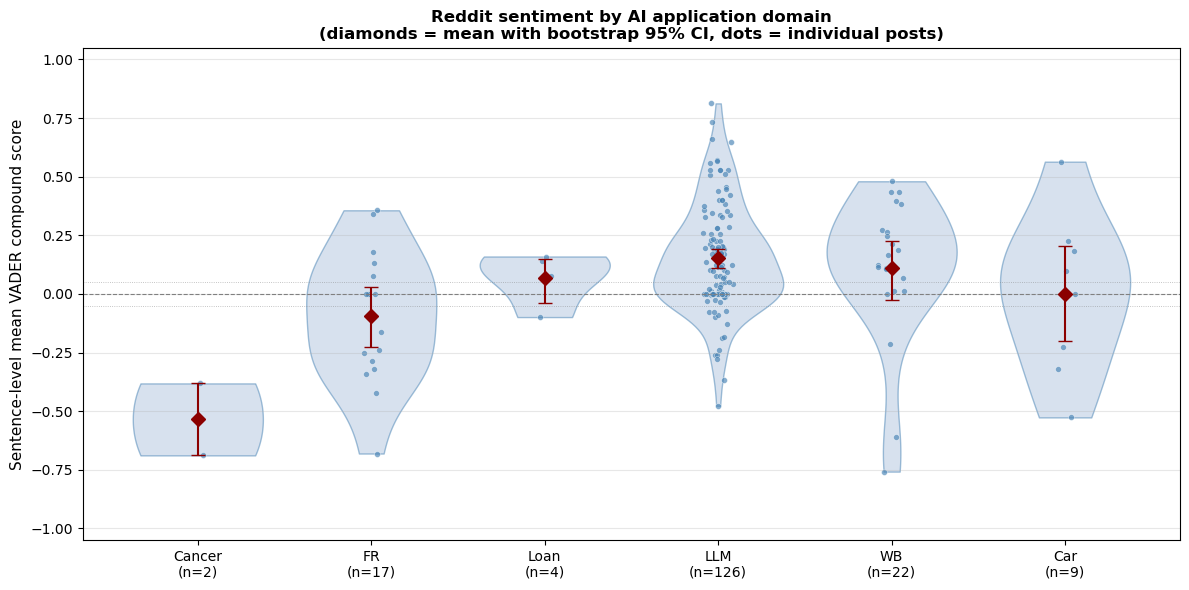

In [51]:
# visualization

plot_domains = [d for d in domain_order
                if (posts_df['assigned_domain'] == d).sum() >= 2]
plot_data = [posts_df.loc[posts_df['assigned_domain'] == d, 'compound_mean'].dropna().values
             for d in plot_domains]
plot_n = [len(v) for v in plot_data]

fig, ax = plt.subplots(figsize=(12, 6))

parts = ax.violinplot(plot_data, showmeans=False, showmedians=False, showextrema=False,
                      widths=0.75)
for pc in parts['bodies']:
    pc.set_facecolor('lightsteelblue')
    pc.set_edgecolor('steelblue')
    pc.set_alpha(0.5)


for i, vals in enumerate(plot_data, start=1):
    jitter = np.random.default_rng(42 + i).normal(0, 0.04, size=len(vals))
    ax.scatter(np.full_like(vals, i) + jitter, vals,
               s=18, color='steelblue', alpha=0.65, edgecolor='white', linewidth=0.4)


for i, d in enumerate(plot_domains, start=1):
    row = sent_summary[sent_summary['Domain'] == d].iloc[0]
    if not np.isnan(row['ci_lo']):
        ax.errorbar(i, row['mean_sent'],
                    yerr=[[row['mean_sent'] - row['ci_lo']],
                          [row['ci_hi'] - row['mean_sent']]],
                    fmt='D', color='darkred', ecolor='darkred',
                    capsize=5, markersize=7, zorder=5)
    else:
        ax.scatter(i, row['mean_sent'], marker='D', color='darkred',
                   s=55, zorder=5)

ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.axhline( 0.05, color='grey', linestyle=':', linewidth=0.6, alpha=0.6)
ax.axhline(-0.05, color='grey', linestyle=':', linewidth=0.6, alpha=0.6)
ax.set_xticks(range(1, len(plot_domains) + 1))
ax.set_xticklabels([f"{d}\n(n={n})" for d, n in zip(plot_domains, plot_n)], fontsize=10)
ax.set_ylabel('Sentence-level mean VADER compound score', fontsize=11)
ax.set_ylim(-1.05, 1.05)
ax.set_title('Reddit sentiment by AI application domain\n'
             '(diamonds = mean with bootstrap 95% CI, dots = individual posts)',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
#plt.savefig('10_vader_by_domain.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# save
out_posts   = CLEAN_DIR / "_all_posts_scored.csv"
out_summary = CLEAN_DIR / "_domain_sentiment_summary.csv"
#posts_df.to_csv(out_posts, index=False)
#sent_summary.to_csv(out_summary, index=False)
print(f"\nsaved:")
print(f"  {out_posts}         ({len(posts_df)} posts with sentence-level + whole-post scores)")
print(f"  {out_summary}  (per-domain descriptive summary)")


saved:
  reddit_clean/_all_posts_scored.csv         (181 posts with sentence-level + whole-post scores)
  reddit_clean/_domain_sentiment_summary.csv  (per-domain descriptive summary)


In [53]:
# spot-check the flagged issues

posts_df = pd.read_csv(CLEAN_DIR / "_all_posts_scored.csv")

# cancer posts
print("="*80)
print(" Cancer posts")
print("="*80)
cancer_posts = posts_df[posts_df['assigned_domain'] == 'Cancer']
for _, row in cancer_posts.iterrows():
    print(f"\n[r/{row['subreddit']}]")
    print(f"  Title:    {row['title']}")
    print(f"  Text:     {row['text_for_vader'][:200]}")
    print(f"  n_sent:   {row['n_sentences']}")
    print(f"  Compound (sentence mean = whole-post): {row['compound_mean']}")
    print(f"  VADER on word 'cancer' alone: {analyzer.polarity_scores('cancer')}")

 Cancer posts

[r/unitedkingdom]
  Title:    AI cancer diagnosis 'might have saved my life'
  Text:     AI cancer diagnosis 'might have saved my life'
  n_sent:   1.0
  Compound (sentence mean = whole-post): -0.3818
  VADER on word 'cancer' alone: {'neg': 1.0, 'neu': 0.0, 'pos': 0.0, 'compound': -0.6597}

[r/unitedkingdom]
  Title:    Major breast cancer screening AI trial to begin
  Text:     Major breast cancer screening AI trial to begin
  n_sent:   1.0
  Compound (sentence mean = whole-post): -0.6887
  VADER on word 'cancer' alone: {'neg': 1.0, 'neu': 0.0, 'pos': 0.0, 'compound': -0.6597}


In [54]:
# WB negative outlier (~ -0.75 in plot)
print("\n" + "="*80)
print(" WB posts sorted by sentiment (check the most negative outlier")
print("="*80)
wb_posts = posts_df[posts_df['assigned_domain'] == 'WB'].sort_values('compound_mean')
for _, row in wb_posts.head(3).iterrows():
    print(f"\n[compound_mean={row['compound_mean']:.3f}, n_sent={row['n_sentences']}] r/{row['subreddit']}")
    print(f"  Title: {row['title']}")
    print(f"  Text preview: {row['text_for_vader'][:300]}")

# RoboCare
print("\n" + "="*80)
print("RoboCare")
print("="*80)
robo_posts = posts_df[posts_df['assigned_domain'] == 'RoboCare']
for _, row in robo_posts.iterrows():
    print(f"\n[r/{row['subreddit']}]")
    print(f"  Title:    {row['title']}")
    print(f"  Text:     {row['text_for_vader'][:300]}")
    print(f"  Compound (sent-mean): {row['compound_mean']}")
    print(f"  Compound (whole-post): {row['compound_wholepost']}")


 WB posts sorted by sentiment (check the most negative outlier

[compound_mean=-0.758, n_sent=1.0] r/unitedkingdom
  Title: DWP algorithm wrongly flags 200,000 people for possible fraud and error
  Text preview: DWP algorithm wrongly flags 200,000 people for possible fraud and error

[compound_mean=-0.612, n_sent=1.0] r/unitedkingdom
  Title: The benefits system is broken – and disabled people pay the price for the DWP's 'poor service'
  Text preview: The benefits system is broken – and disabled people pay the price for the DWP's 'poor service'

[compound_mean=-0.214, n_sent=5.0] r/AskUK
  Title: WTH is going on with the benefits reform? Yes pip is highly claimed however it is already very difficult to get and the dwp has even said fraud is at 0% compared to universal credit which is 11%
  Text preview: WTH is going on with the benefits reform? Yes pip is highly claimed however it is already very difficult to get and the dwp has even said fraud is at 0% compared to universal credit wh

In [55]:
# sentence-level vs whole-post divergence per post
print("\n" + "="*80)
print(" per-post divergence between sentence-mean and whole-post compound")
print("="*80)
posts_df['divergence'] = posts_df['compound_wholepost'] - posts_df['compound_mean']
print("\nDivergence stats overall:")
print(posts_df['divergence'].describe().round(3).to_string())
print("\ndivergence by domain (mean):")
div_by_domain = posts_df.groupby('assigned_domain').agg(
    n=('compound_mean', 'size'),
    div_mean=('divergence', 'mean'),
    div_median=('divergence', 'median'),
    n_sent_median=('n_sentences', 'median'),
).round(3)
print(div_by_domain.to_string())


 per-post divergence between sentence-mean and whole-post compound

Divergence stats overall:
count    181.000
mean       0.224
std        0.454
min       -0.948
25%        0.000
50%        0.111
75%        0.634
max        0.930

divergence by domain (mean):
                   n  div_mean  div_median  n_sent_median
assigned_domain                                          
Cancer             2     0.000       0.000            1.0
Car                9     0.153       0.000            1.0
FR                17     0.015       0.000            1.0
LLM              126     0.244       0.201            4.0
Loan               4     0.440       0.802           25.5
RoboCare           1     0.557       0.557            8.0
WB                22     0.265       0.302            5.5


In [56]:
# correlation
from scipy.stats import spearmanr
rho, p = spearmanr(posts_df['n_sentences'], posts_df['divergence'])
print(f"\n spearman(n_sentences, divergence) = {rho:.3f}, p = {p:.2e}")


 spearman(n_sentences, divergence) = 0.540, p = 4.35e-15


In [57]:
from itertools import permutations
from scipy.stats import spearmanr

In [58]:
#cross-modal alignment: spearman rank correlation

# assemble the two ranking sources

survey_concern = {
    'Car':      3.062,
    'Chatbot':  2.854,
    'RoboCare': 2.788,
    'WB':       2.728,
    'LLM':      2.543,
    'Loan':     2.539,
    'FR':       2.282,
    'Cancer':   2.175,
}

# Reddit sentiment

sent_summary = pd.read_csv(CLEAN_DIR / "_domain_sentiment_summary.csv")
reddit_sent = dict(zip(sent_summary['Domain'], sent_summary['mean_sent']))
reddit_n    = dict(zip(sent_summary['Domain'], sent_summary['n']))


# convert to "negative" -- both axes point in the same direction
# (higher on both = more negative / concerning
reddit_neg = {d: -v for d, v in reddit_sent.items() if not pd.isna(v)}

print("="*80)
print("Rankings source table")
print("="*80)
combined = pd.DataFrame({
    'domain':        list(survey_concern.keys()),
    'survey_concern': [survey_concern[d] for d in survey_concern],
    'reddit_mean_compound': [reddit_sent.get(d, np.nan) for d in survey_concern],
    'reddit_neg_intensity': [reddit_neg.get(d, np.nan) for d in survey_concern],
    'reddit_n':      [reddit_n.get(d, 0) for d in survey_concern],
})
# assign inclusion tag
def inclusion(row):
    if row['reddit_n'] == 0:
        return 'excluded: n=0'
    if row['domain'] == 'Cancer':
        return 'excluded: VADER lexicon bias (see Discussion)'
    if row['domain'] == 'RoboCare':
        return 'excluded: semantic false positive + n=1'
    if row['reddit_n'] < 10:
        return f'sensitivity only (n={row["reddit_n"]} < 10)'
    return 'primary'
combined['inclusion'] = combined.apply(inclusion, axis=1)
print(combined.to_string(index=False))

Rankings source table
  domain  survey_concern  reddit_mean_compound  reddit_neg_intensity  reddit_n                                     inclusion
     Car           3.062               -0.0001                0.0001         9                   sensitivity only (n=9 < 10)
 Chatbot           2.854                   NaN                   NaN         0                                 excluded: n=0
RoboCare           2.788                0.1557               -0.1557         1       excluded: semantic false positive + n=1
      WB           2.728                0.1111               -0.1111        22                                       primary
     LLM           2.543                0.1512               -0.1512       126                                       primary
    Loan           2.539                0.0691               -0.0691         4                   sensitivity only (n=4 < 10)
      FR           2.282               -0.0949                0.0949        17                         

In [59]:
# Exact permutation p-value for Spearman on small n

def spearman_with_exact_p(x, y):
    """
    Compute Spearman rho and an exact two-sided p-value by enumerating
    all n! permutations of y. Suitable for very small n (up to ~10).
    Returns (rho, p_exact, n).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    assert len(y) == n
    rho_obs, _ = spearmanr(x, y)

    # enumerate permutations of y, compute rho; count |rho| >= |rho_obs|
    count_extreme = 0
    total = 0
    for perm in permutations(range(n)):
        y_perm = y[list(perm)]
        rho_perm, _ = spearmanr(x, y_perm)
        if abs(rho_perm) >= abs(rho_obs) - 1e-12:
            count_extreme += 1
        total += 1
    p_exact = count_extreme / total
    return rho_obs, p_exact, n

In [61]:
# primary + sensitivity analysis

import math

def run_alignment(domain_list, label):
    print("\n" + "="*80)
    print(f"{label}")
    print(f"Domains ({len(domain_list)}): {domain_list}")
    print("="*80)
    x = np.array([survey_concern[d] for d in domain_list])
    y = np.array([reddit_neg[d]     for d in domain_list])

    # Ranks for transparency
    df_ranks = pd.DataFrame({
        'domain':               domain_list,
        'survey_concern':       x,
        'survey_rank':          pd.Series(x).rank(ascending=True).values,   # 1=lowest concern, n=highest
        'reddit_neg_intensity': y,
        'reddit_rank':          pd.Series(y).rank(ascending=True).values,   # 1=most positive, n=most negative
    })
    df_ranks['rank_diff'] = df_ranks['survey_rank'] - df_ranks['reddit_rank']
    print("\nRankings side-by-side (rank 1 = lowest concern / most positive sentiment):")
    print(df_ranks.round(3).to_string(index=False))

    rho, p_exact, n = spearman_with_exact_p(x, y)
    # report asymptotic p for comparison
    _, p_asym = spearmanr(x, y)
    print(f"\nSpearman rho     = {rho:+.3f}")
    print(f"Exact two-sided p = {p_exact:.4f}  ({int(round(p_exact * math.factorial(n)))}/{math.factorial(n)} permutations at least as extreme)")
    print(f"asymptotic p      = {p_asym:.4f}  (for comparison; unreliable at small n)")
    print(f"n (domains)       = {n}")
    return df_ranks, rho, p_exact, n


primary_domains = ['FR', 'LLM', 'WB', 'Car']      # all n >= 10
sens1_domains   = ['FR', 'LLM', 'WB', 'Car', 'Loan']  # + Loan (n=4)

primary_ranks, primary_rho, primary_p, primary_n = run_alignment(
    primary_domains, "PRIMARY: n >= 10 domains"
)
sens1_ranks, sens1_rho, sens1_p, sens1_n = run_alignment(
    sens1_domains, "SENSITIVITY 1: primary + Loan (n=4)"
)

print("\n" + "="*65)
print("Note: Chatbot (n=0) is impossible to include")
print("      Cancer and RoboCare are excluded for the reasons documented in the inclusion table above.")
print("="*65)


PRIMARY: n >= 10 domains
Domains (4): ['FR', 'LLM', 'WB', 'Car']

Rankings side-by-side (rank 1 = lowest concern / most positive sentiment):
domain  survey_concern  survey_rank  reddit_neg_intensity  reddit_rank  rank_diff
    FR           2.282          1.0                 0.095          4.0       -3.0
   LLM           2.543          2.0                -0.151          1.0        1.0
    WB           2.728          3.0                -0.111          2.0        1.0
   Car           3.062          4.0                 0.000          3.0        1.0

Spearman rho     = -0.200
Exact two-sided p = 0.9167  (22/24 permutations at least as extreme)
asymptotic p      = 0.8000  (for comparison; unreliable at small n)
n (domains)       = 4

SENSITIVITY 1: primary + Loan (n=4)
Domains (5): ['FR', 'LLM', 'WB', 'Car', 'Loan']

Rankings side-by-side (rank 1 = lowest concern / most positive sentiment):
domain  survey_concern  survey_rank  reddit_neg_intensity  reddit_rank  rank_diff
    FR           2.

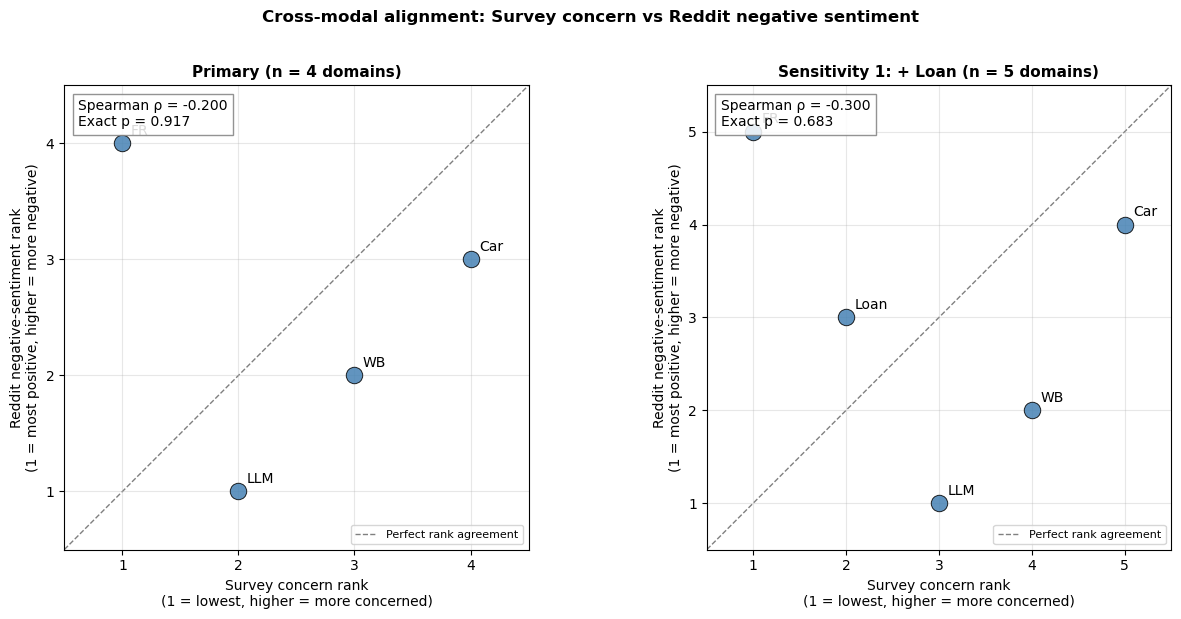

In [62]:
# visualization

# 2-panel plot: primary + sensitivity, survey-rank vs reddit-rank scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False)

for ax, (ranks_df, rho, p_exact, n, title) in zip(
    axes,
    [(primary_ranks, primary_rho, primary_p, primary_n,
      f'Primary (n = {primary_n} domains)'),
     (sens1_ranks, sens1_rho, sens1_p, sens1_n,
      f'Sensitivity 1: + Loan (n = {sens1_n} domains)')]
):
    x_r = ranks_df['survey_rank'].values
    y_r = ranks_df['reddit_rank'].values
    ax.scatter(x_r, y_r, s=140, color='steelblue', alpha=0.85,
               edgecolor='black', linewidth=0.7, zorder=3)
    # domain labels
    for _, r in ranks_df.iterrows():
        ax.annotate(r['domain'], (r['survey_rank'], r['reddit_rank']),
                    xytext=(6, 6), textcoords='offset points', fontsize=10)
    # y=x reference line
    lo = 0.5
    hi = n + 0.5
    ax.plot([lo, hi], [lo, hi], color='grey', linestyle='--', linewidth=1,
            label='Perfect rank agreement', zorder=1)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks(range(1, n + 1)); ax.set_yticks(range(1, n + 1))
    ax.set_xlabel('Survey concern rank\n(1 = lowest, higher = more concerned)', fontsize=10)
    ax.set_ylabel('Reddit negative-sentiment rank\n(1 = most positive, higher = more negative)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.text(0.03, 0.97,
            f'Spearman ρ = {rho:+.3f}\nExact p = {p_exact:.3f}',
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(facecolor='white', edgecolor='grey', alpha=0.85))
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Cross-modal alignment: Survey concern vs Reddit negative sentiment',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('11_spearman_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

In [63]:
# save
out_ranks = CLEAN_DIR / "_alignment_ranks.csv"
#combined.to_csv(out_ranks, index=False)
print(f"\nsaved:  {out_ranks}  (full domain table with inclusion tags")


saved:  reddit_clean/_alignment_ranks.csv  (full domain table with inclusion tags


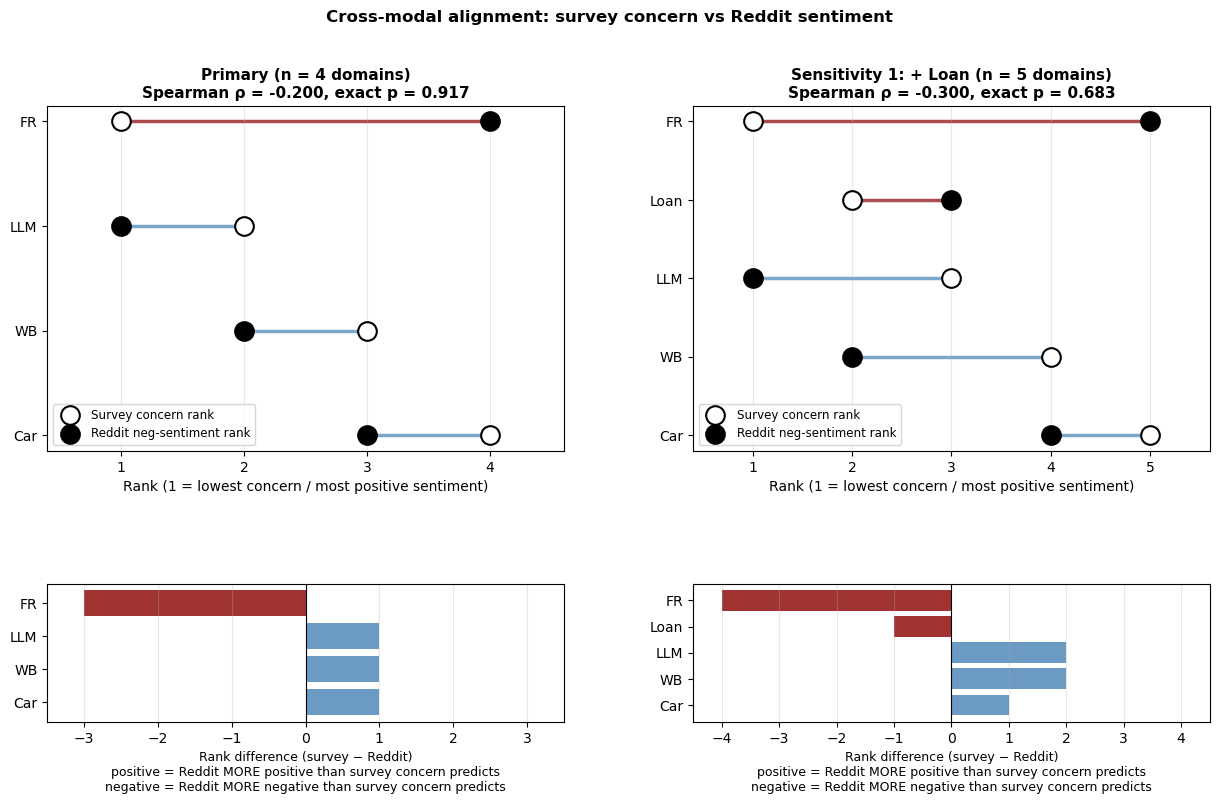

In [68]:
# revised visualization: dumbbell + rank_diff bar

def plot_dumbbell(ax_top, ax_bot, ranks_df, rho, p_exact, title):
    n = len(ranks_df)

    df = ranks_df.sort_values('survey_rank').reset_index(drop=True)
    y_pos = np.arange(len(df))

    for i, row in df.iterrows():

        colour = 'darkred'  if row['rank_diff'] < 0 else 'steelblue' if row['rank_diff'] > 0 else 'grey'
        ax_top.plot([row['survey_rank'], row['reddit_rank']],
                    [i, i], color=colour, linewidth=2.5, alpha=0.7, zorder=1)
    ax_top.scatter(df['survey_rank'], y_pos, s=180, color='white',
                   edgecolor='black', linewidth=1.5, zorder=3, label='Survey concern rank')
    ax_top.scatter(df['reddit_rank'], y_pos, s=180, color='black',
                   edgecolor='black', linewidth=1.5, zorder=3, label='Reddit neg-sentiment rank')

    ax_top.set_yticks(y_pos)
    ax_top.set_yticklabels(df['domain'], fontsize=10)
    ax_top.set_xticks(range(1, n + 1))
    ax_top.set_xlim(0.4, n + 0.6)
    ax_top.set_xlabel('Rank (1 = lowest concern / most positive sentiment)', fontsize=10)
    ax_top.set_title(f'{title}\nSpearman ρ = {rho:+.3f}, exact p = {p_exact:.3f}',
                     fontsize=11, fontweight='bold')
    ax_top.grid(axis='x', alpha=0.3)
    ax_top.legend(fontsize=8.5, loc='lower left', framealpha=0.8)
    ax_top.invert_yaxis()


    colours = ['darkred' if v < 0 else 'steelblue' if v > 0 else 'grey'
               for v in df['rank_diff'].values]
    ax_bot.barh(y_pos, df['rank_diff'].values, color=colours, alpha=0.8)
    ax_bot.axvline(0, color='black', linewidth=0.8)
    ax_bot.set_yticks(y_pos); ax_bot.set_yticklabels(df['domain'], fontsize=10)
    ax_bot.set_xlabel('Rank difference (survey − Reddit)\n'
                      'positive = Reddit MORE positive than survey concern predicts\n'
                      'negative = Reddit MORE negative than survey concern predicts',
                      fontsize=9)
    ax_bot.grid(axis='x', alpha=0.3)
    ax_bot.invert_yaxis()
    max_abs = max(abs(df['rank_diff'].min()), abs(df['rank_diff'].max()))
    ax_bot.set_xlim(-max_abs - 0.5, max_abs + 0.5)


fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[2.5, 1], hspace=0.55, wspace=0.25)

ax_tp = fig.add_subplot(gs[0, 0])
ax_bp = fig.add_subplot(gs[1, 0])
ax_ts = fig.add_subplot(gs[0, 1])
ax_bs = fig.add_subplot(gs[1, 1])

plot_dumbbell(ax_tp, ax_bp, primary_ranks, primary_rho, primary_p,
              f'Primary (n = {primary_n} domains)')
plot_dumbbell(ax_ts, ax_bs, sens1_ranks, sens1_rho, sens1_p,
              f'Sensitivity 1: + Loan (n = {sens1_n} domains)')

fig.suptitle('Cross-modal alignment: survey concern vs Reddit sentiment',
             fontsize=12, fontweight='bold', y=1.00)
#plt.tight_layout()
#plt.savefig('11_spearman_alignment_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [69]:
# compare Reddit negative sentiment against each LCA class's

from scipy.stats import spearmanr, pearsonr

# concern profiles per source

concern_by_source = {
    'Population':  {'FR': 2.282, 'WB': 2.728, 'LLM': 2.543, 'Loan': 2.539, 'Car': 3.062},
    'Enthusiasts': {'FR': 1.800, 'WB': 2.087, 'LLM': 2.021, 'Loan': 1.998, 'Car': 2.537},
    'Moderates':   {'FR': 2.457, 'WB': 2.875, 'LLM': 2.693, 'Loan': 2.667, 'Car': 3.162},
    'Sceptics':    {'FR': 2.603, 'WB': 3.282, 'LLM': 2.985, 'Loan': 3.010, 'Car': 3.550},
}

sent_summary = pd.read_csv(CLEAN_DIR / "_domain_sentiment_summary.csv")
reddit_sent  = dict(zip(sent_summary['Domain'], sent_summary['mean_sent']))
reddit_neg   = {d: -v for d, v in reddit_sent.items() if not pd.isna(v)}

primary_domains = ['FR', 'LLM', 'WB', 'Car']
sens1_domains   = ['FR', 'LLM', 'WB', 'Car', 'Loan']

In [70]:
# Exact permutation p for Pearson and Spearman

def exact_permutation_p(x, y, stat='pearson'):
    """
    Exact two-sided p by enumerating all n! permutations of y.
    stat: 'pearson' or 'spearman'.
    Returns (statistic, p_exact).
    """
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    n = len(x)
    if stat == 'pearson':
        r_obs, _ = pearsonr(x, y)
        get_stat = lambda a, b: pearsonr(a, b)[0]
    else:
        r_obs, _ = spearmanr(x, y)
        get_stat = lambda a, b: spearmanr(a, b)[0]
    count = 0
    total = 0
    for perm in permutations(range(n)):
        r_perm = get_stat(x, y[list(perm)])
        if abs(r_perm) >= abs(r_obs) - 1e-12:
            count += 1
        total += 1
    return r_obs, count / total

In [71]:
# run alignment for each source x each domain set

def run_class_alignment(domain_list, label):
    print("\n" + "="*70)
    print(f"{label}   |   n_domains = {len(domain_list)}   |   {domain_list}")
    print("="*70)
    reddit_vec = np.array([reddit_neg[d] for d in domain_list])
    rows = []
    for source, concern_dict in concern_by_source.items():
        survey_vec = np.array([concern_dict[d] for d in domain_list])
        r_p, p_p = exact_permutation_p(survey_vec, reddit_vec, stat='pearson')
        r_s, p_s = exact_permutation_p(survey_vec, reddit_vec, stat='spearman')
        rows.append({
            'Source': source,
            'Pearson r':  round(r_p, 3),
            'Pearson exact p': round(p_p, 4),
            'Spearman rho': round(r_s, 3),
            'Spearman exact p': round(p_s, 4),
        })
    out = pd.DataFrame(rows)
    print(out.to_string(index=False))
    return out

primary_align = run_class_alignment(primary_domains, "PRIMARY (n=4 domains, all with Reddit n>=10)")
sens1_align   = run_class_alignment(sens1_domains,   "SENSITIVITY 1 (+ Loan, n=5 domains)")


PRIMARY (n=4 domains, all with Reddit n>=10)   |   n_domains = 4   |   ['FR', 'LLM', 'WB', 'Car']
     Source  Pearson r  Pearson exact p  Spearman rho  Spearman exact p
 Population     -0.244           0.7917          -0.2            0.9167
Enthusiasts     -0.127           0.9167          -0.2            0.9167
  Moderates     -0.254           0.7917          -0.2            0.9167
   Sceptics     -0.362           0.5833          -0.2            0.9167

SENSITIVITY 1 (+ Loan, n=5 domains)   |   n_domains = 5   |   ['FR', 'LLM', 'WB', 'Car', 'Loan']
     Source  Pearson r  Pearson exact p  Spearman rho  Spearman exact p
 Population     -0.216           0.7167          -0.3            0.6833
Enthusiasts     -0.101           0.8833          -0.3            0.6833
  Moderates     -0.218           0.7167          -0.3            0.6833
   Sceptics     -0.341           0.6000          -0.1            0.9500


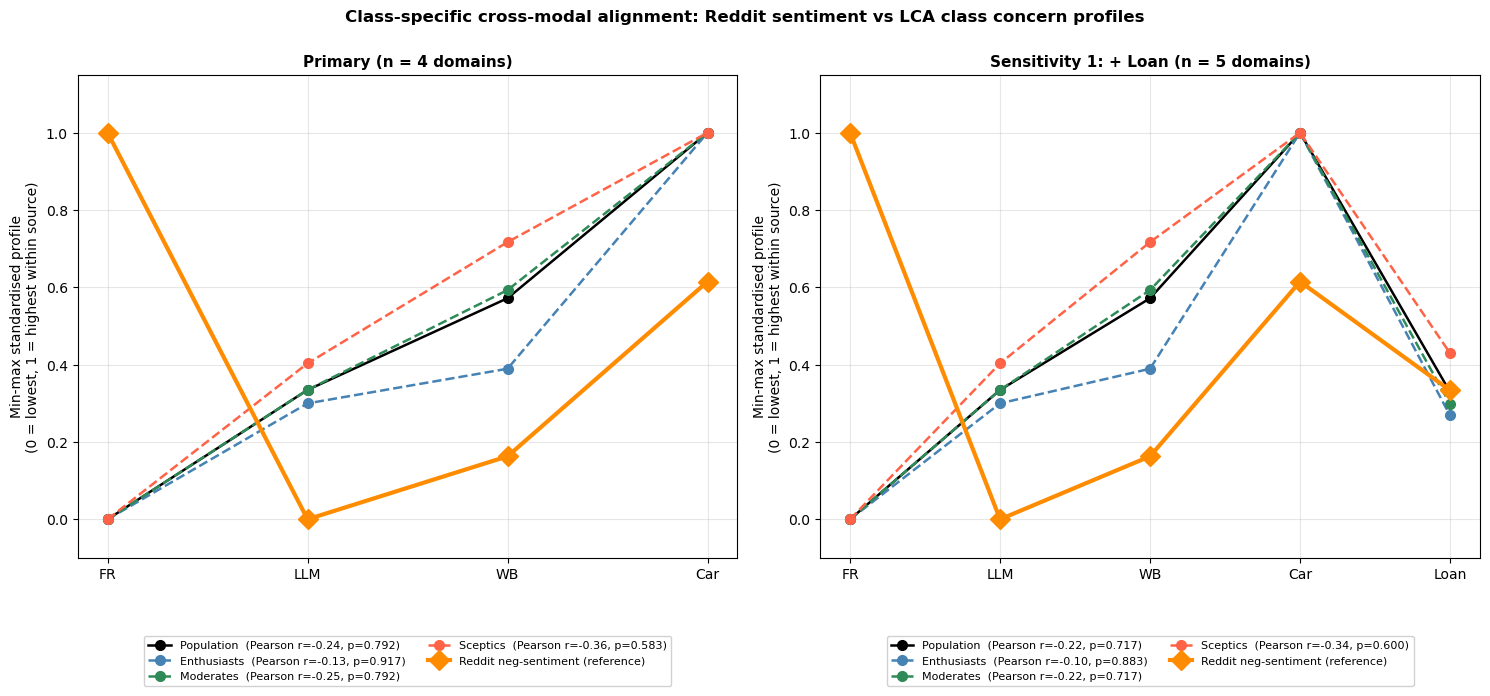

In [72]:
# visualisation

def minmax(vec):
    vec = np.asarray(vec, dtype=float)
    if vec.max() == vec.min():
        return np.zeros_like(vec)
    return (vec - vec.min()) / (vec.max() - vec.min())

def plot_class_alignment(domain_list, align_df, ax, title):
    n = len(domain_list)
    x = np.arange(n)
    reddit_vec = np.array([reddit_neg[d] for d in domain_list])
    reddit_std = minmax(reddit_vec)

    colours = {
        'Population':  'black',
        'Enthusiasts': 'steelblue',
        'Moderates':   'seagreen',
        'Sceptics':    'tomato',
    }
    styles = {
        'Population':  '-',
        'Enthusiasts': '--',
        'Moderates':   '--',
        'Sceptics':    '--',
    }
    for source, concern_dict in concern_by_source.items():
        survey_vec = np.array([concern_dict[d] for d in domain_list])
        survey_std = minmax(survey_vec)
        r_row = align_df.loc[align_df['Source'] == source].iloc[0]
        ax.plot(x, survey_std, marker='o', color=colours[source],
                linestyle=styles[source], linewidth=1.8, markersize=7,
                label=f"{source}  (Pearson r={r_row['Pearson r']:+.2f}, p={r_row['Pearson exact p']:.3f})")

    # Reddit profile (highlight
    ax.plot(x, reddit_std, marker='D', color='darkorange',
            linestyle='-', linewidth=3, markersize=10,
            label='Reddit neg-sentiment (reference)', zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels(domain_list, fontsize=10)
    ax.set_ylabel('Min-max standardised profile\n(0 = lowest, 1 = highest within source)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(-0.1, 1.15)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              ncol=2, framealpha=0.9)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
plot_class_alignment(primary_domains, primary_align, axes[0],
                     f'Primary (n = {len(primary_domains)} domains)')
plot_class_alignment(sens1_domains, sens1_align, axes[1],
                     f'Sensitivity 1: + Loan (n = {len(sens1_domains)} domains)')
fig.suptitle('Class-specific cross-modal alignment: Reddit sentiment vs LCA class concern profiles',
             fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
#plt.savefig('12_class_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

In [73]:
# deviation summary

def deviation_summary(domain_list, label):
    print("\n" + "="*70)
    print(f"Reddit_vs_source deviation summary — {label}")
    print("="*70)
    reddit_vec = np.array([reddit_neg[d] for d in domain_list])
    reddit_std = minmax(reddit_vec)
    rows = []
    for source, concern_dict in concern_by_source.items():
        survey_vec = np.array([concern_dict[d] for d in domain_list])
        survey_std = minmax(survey_vec)
        mad  = np.mean(np.abs(reddit_std - survey_std))
        rmsd = np.sqrt(np.mean((reddit_std - survey_std) ** 2))
        rows.append({'Source': source,
                     'MAD (standardised)': round(mad, 3),
                     'RMSD (standardised)': round(rmsd, 3)})
    out = pd.DataFrame(rows).sort_values('MAD (standardised)')
    print(out.to_string(index=False))
    return out

primary_dev = deviation_summary(primary_domains, "Primary")
sens1_dev   = deviation_summary(sens1_domains,   "Sensitivity 1")


# save
#primary_align.to_csv(CLEAN_DIR / "_class_alignment_primary.csv", index=False)
#sens1_align.to_csv(CLEAN_DIR / "_class_alignment_sens1.csv", index=False)
print(f"\nSaved class alignment tables to {CLEAN_DIR}/")


Reddit_vs_source deviation summary — Primary
     Source  MAD (standardised)  RMSD (standardised)
Enthusiasts               0.478                0.568
 Population               0.532                0.597
  Moderates               0.537                0.601
   Sceptics               0.586                0.636

Reddit_vs_source deviation summary — Sensitivity 1
     Source  MAD (standardised)  RMSD (standardised)
Enthusiasts               0.395                0.509
 Population               0.427                0.534
  Moderates               0.437                0.538
   Sceptics               0.488                0.570

Saved class alignment tables to reddit_clean/
